# Connecticut Housing Sales: Cleaning, Categorizing, and Price Prediction
**Author:** Mario Perez  
**Dataset:** CT Office of Policy and Management — Real Estate Sales 2001–2023  
**Source:** https://catalog.data.gov/dataset/real-estate-sales-2001-2018  
**Last Updated:** 2024

## Executive Summary

**Problem:** Connecticut housing sale records contain inconsistent remarks,
invalid transactions, and incomplete property data, making price prediction
unreliable without careful preprocessing.

**Approach:**
- Cleaned and filtered 1.1M transactions (2001–2023)
- Built an OOP remarks classifier (RemarksProcessor) to normalize
  79,000+ unique assessor remarks into meaningful categories
- Engineered features including flip detection, home age, and
  town-level YoY price growth
- Trained XGBoost with Bayesian optimization

**Key Results:**
- Final model RMSE: $115,231 on held-out test set
- 60.9% of predictions within $50K of actual price
- A/B test: XGBoost significantly outperforms Ridge (p=0.0263)
- When property details available: RMSE improves to $101,829
- Built composite investment score ranking all 170 CT towns

**Key Findings:**
- Assessed Value and town identity are the two strongest price predictors
- Emerging urban markets (Hartford, Waterbury, Meriden) score highest
  on investment potential — not the Gold Coast luxury towns
- Foreclosure sales average 27% below market value
- Data completeness is the primary bottleneck — collecting Sqft/Beds
  for the remaining 76% of records would likely push RMSE below $100K

## Business Problem

Housing sale records in Connecticut often contain unclear, inconsistent
remarks and invalid or special-case transactions that reduce data quality
and model reliability.

This project aims to:
1. Clean and categorize messy transaction remarks at scale
2. Engineer features that capture market dynamics and property characteristics
3. Train a reliable model to predict residential sale prices
4. Identify which Connecticut towns offer the best investment potential
5. Deliver findings through an interactive Streamlit application

## Dataset Overview

**Primary dataset:** CT Real Estate Sales 2001–2023 (data.gov)  
**Secondary dataset:** Scraped property details via HomeHarvest (2015–2024)  
**Merged shape:** 1,144,647 rows × 18 columns  
**Target variable:** Sale Amount  

| Column | Type | Description |
|--------|------|-------------|
| Serial Number | int | Unique transaction ID |
| List Year | datetime | Year property was listed |
| Date Recorded | datetime | Date sale was recorded |
| Town | object | CT town name (170 unique) |
| Address | object | Street address |
| Assessed Value | float | Town-assessed property value |
| Sale Amount | float | Actual sale price (target) |
| Sales Ratio | float | Assessed/Sale ratio (97% missing) |
| Property Type | object | e.g. Single Family, Condo |
| Residential Type | object | Subcategory of residential |
| Non Use Code | object | Reason sale may be non-market |
| Assessor Remarks | object | Free text notes from assessor |
| OPM remarks | object | Free text notes from OPM |
| Location | object | Lat/lon string (70% missing) |
| Beds | float | Bedrooms (76% missing) |
| Garage | float | Garage spaces (91% missing) |
| Sqft | float | Square footage (76% missing) |
| Year Built | float | Year home was built (76% missing) |

In [202]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# ── Machine Learning — Preprocessing ─────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer

# ── Machine Learning — Models ─────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import xgboost as xgb

# ── Machine Learning — Evaluation ─────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    cross_val_predict, KFold
)
from sklearn.metrics import mean_squared_error

# ── Hyperparameter Optimization ───────────────────────────────────────────────
from bayes_opt import BayesianOptimization

# ── Statistical Testing ───────────────────────────────────────────────────────
from scipy import stats

# ── Model Persistence ─────────────────────────────────────────────────────────
import joblib

# ── Explainability ────────────────────────────────────────────────────────────
import shap

# ── Global Settings ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
TARGET_COL   = 'Sale Amount'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 1. Data Loading
Load the government real estate dataset and scraped property details,
then merge on address and town.

In [203]:
# https://catalog.data.gov/dataset/real-estate-sales-2001-2018
import numpy as np
import pandas as pd
import re

df = pd.read_csv('Real_Estate_Sales_2001-2023_GL.csv')
df.head(10)

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",0.54,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014)
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",0.46,Residential,Three Family,NaN,NaN,NaN,NaN
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",0.46,Commercial,NaN,NaN,NaN,NaN,NaN
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,"127,400.00","202,500.00",0.63,Residential,Two Family,NaN,NaN,NaN,NaN
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",0.50,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988)
5,200500,2020,09/07/2021,Avon,245 NEW ROAD,"217,640.00","400,000.00",0.54,Residential,Single Family,NaN,NaN,NaN,NaN
6,200121,2020,12/15/2020,Avon,63 NORTHGATE,"528,490.00","775,000.00",0.68,Residential,Single Family,NaN,NaN,NaN,POINT (-72.89675 41.79445)
7,20058,2020,06/01/2021,Barkhamsted,46 RATLUM MTN RD,"203,530.00","415,000.00",0.49,Residential,Single Family,NaN,"2003 COLONIAL, 2140 SFLA, 2.99 AC",NaN,NaN
8,200046,2020,01/25/2021,Beacon Falls,34 LASKY ROAD,"158,030.00","243,000.00",0.65,Residential,Single Family,NaN,NaN,NaN,NaN
9,200016,2020,11/13/2020,Beacon Falls,9 AVON COURT,"65,590.00","100,000.00",0.66,Residential,Condo,NaN,NaN,NaN,NaN


In [204]:
''' 
from homeharvest import scrape_property
from datetime import datetime
import pandas as pd
import time

#https://github.com/ZacharyHampton/HomeHarvest

# Replace with your full list of towns if running this in full
towns = [
    'East Lyme', 'Putnam', 'Glastonbury', 'Chester', 'Danbury', 'Brooklyn', 'Fairfield', 'New Haven', 'Newtown',
    'New Fairfield', 'Rocky Hill', 'Bridgeport', 'Stonington', 'Naugatuck', 'Windsor', 'Waterbury', 'Manchester',
    'Middletown', 'Oxford', 'Clinton', 'Ansonia', 'Ridgefield', 'Southbury', 'Torrington', 'Vernon', 'Stafford',
    'West Haven', 'East Hampton', 'Stamford', 'East Haven', 'Norwalk', 'Salem', 'Somers', 'Haddam', 'Wethersfield',
    'East Hartford', 'Hamden', 'Bloomfield', 'Hartford', 'Canterbury', 'Branford', 'Old Lyme', 'Milford', 'Meriden',
    'Farmington', 'Mansfield', 'Thomaston', 'Woodstock', 'Wallingford', 'Cornwall', 'North Canaan', 'South Windsor',
    'Bristol', 'Enfield', 'Berlin', 'Simsbury', 'Cromwell', 'Newington', 'Brookfield', 'Voluntown', 'New Britain',
    'West Hartford', 'Ellington', 'Groton', 'Shelton', 'Guilford', 'Tolland', 'Coventry', 'Montville', 'Trumbull',
    'Canaan', 'Stratford', 'Windsor Locks', 'Southington', 'Portland', 'Willington', 'Griswold', 'East Haddam',
    'Winchester', 'Monroe', 'Woodbridge', 'Plainville', 'Morris', 'Ledyard', 'North Branford', 'Thompson', 'Waterford',
    'Middlebury', 'Deep River', 'Plymouth', 'Seymour', 'Bethel', 'Ashford', 'Derby', 'New Milford', 'Granby', 'Greenwich',
    'Bozrah', 'Sterling', 'Plainfield', 'Goshen', 'Westport', 'Preston', 'North Haven', 'Wolcott', 'Easton', 'Pomfret',
    'Hebron', 'Durham', 'Killingworth', 'Orange', 'Salisbury', 'Norfolk', 'Westbrook', 'Canton', 'Colebrook', 'Roxbury',
    'Columbia', 'Colchester', 'North Stonington', 'Andover', 'Beacon Falls', 'Bridgewater', 'Middlefield', 'Redding',
    'Hartland', 'Prospect', 'Sprague', 'Warren', 'Lisbon', 'Marlborough', 'Bethany', 'Suffield', 'Litchfield', 'New London',
    'Madison', 'Killingly', 'Old Saybrook', 'Watertown', 'Essex', 'Woodbury', 'Norwich', 'East Granby', 'Burlington',
    'Sherman', 'Windham', 'Avon', 'East Windsor', 'Cheshire', 'Chaplin', 'Bolton', 'Eastford', 'New Canaan', 'Wilton',
    'Bethlehem', 'Hampton', 'New Hartford', 'Darien', 'Barkhamsted', 'Lebanon', 'Sharon', 'Franklin', 'Lyme', 'Weston',
    'Kent', 'Harwinton', 'Washington', 'Scotland', 'Union'
]

start_year = 2015
end_year = 2024

# Where we'll store extracted records
all_records = []

for town in towns:
    print(f"\n📍 Scraping data for: {town}")

    for year in range(start_year, end_year + 1):
        date_from = f"{year}-01-01"
        date_to = f"{year}-12-31"

        try:
            # Use Pydantic to access full structure
            properties = scrape_property(
                location=f"{town}, CT",
                listing_type="sold",
                date_from=date_from,
                date_to=date_to,
                return_type="pydantic",
                limit=10000
            )

            if not properties:
                print(f"  - {year}: No properties found")
                continue

            for prop in properties:
                try:
                    record = {
                        "Formatted Address": getattr(prop.address, "formatted_address", "Unknown") if prop.address else "Unknown",
                        "City": getattr(prop.address, "city", "Unknown") if prop.address else "Unknown",
                        "Beds": getattr(prop.description, "beds", "Unknown") if prop.description else "Unknown",
                        "Baths": getattr(prop.description, "full_baths", "Unknown") if prop.description else "Unknown",
                        "Garage": getattr(prop.description, "garage", "Unknown") if prop.description else "Unknown",
                        "Sqft": getattr(prop.description, "sqft", "Unknown") if prop.description else "Unknown",
                        "Year Built": getattr(prop.description, "year_built", "Unknown") if prop.description else "Unknown",
                        "Sold Price": getattr(prop, "sold_price", "Unknown"),
                        "Sold Date": getattr(prop, "last_sold_date", "Unknown"),
                        "Source Town": town,
                        "Source Year": year
                    }
                    all_records.append(record)
                    
                except Exception as inner_e:
                    print(f"    ⚠️ Skipping a property due to error: {inner_e}")

            print(f"  ✓ {year}: {len(properties)} properties found")

        except Exception as e:
            print(f"  ✗ Error for {town}, {year}: {e}")
            continue

        time.sleep(1)  # Respectful pause to avoid being rate-limited

# Convert to DataFrame and save
if all_records:
    df_scraped = pd.DataFrame(all_records)
    df_scraped.to_csv("ct_sold_properties_detailed_2015_2024.csv", index=False)
    print("\n✅ Scraping complete. File saved as 'ct_sold_properties_detailed_2015_2024.csv'")
else:
    print("\n⚠️ No data scraped.")
'''

' \nfrom homeharvest import scrape_property\nfrom datetime import datetime\nimport pandas as pd\nimport time\n\n#https://github.com/ZacharyHampton/HomeHarvest\n\n# Replace with your full list of towns if running this in full\ntowns = [\n    \'East Lyme\', \'Putnam\', \'Glastonbury\', \'Chester\', \'Danbury\', \'Brooklyn\', \'Fairfield\', \'New Haven\', \'Newtown\',\n    \'New Fairfield\', \'Rocky Hill\', \'Bridgeport\', \'Stonington\', \'Naugatuck\', \'Windsor\', \'Waterbury\', \'Manchester\',\n    \'Middletown\', \'Oxford\', \'Clinton\', \'Ansonia\', \'Ridgefield\', \'Southbury\', \'Torrington\', \'Vernon\', \'Stafford\',\n    \'West Haven\', \'East Hampton\', \'Stamford\', \'East Haven\', \'Norwalk\', \'Salem\', \'Somers\', \'Haddam\', \'Wethersfield\',\n    \'East Hartford\', \'Hamden\', \'Bloomfield\', \'Hartford\', \'Canterbury\', \'Branford\', \'Old Lyme\', \'Milford\', \'Meriden\',\n    \'Farmington\', \'Mansfield\', \'Thomaston\', \'Woodstock\', \'Wallingford\', \'Cornwall\', \

In [205]:
df2 = pd.read_csv('ct_sold_properties_detailed_2015_2024.csv')
df2.head()

,Formatted Address,City,Beds,Baths,Garage,Sqft,Year Built,Sold Price,Sold Date,Source Town,Source Year
0,"39 Greencliff Dr, Niantic, CT, 06357",Niantic,3.00,Unknown,NaN,"1,894.00","1,979.00",Unknown,12/30/2015 0:00,East Lyme,2015
1,"27 Spring Rock Rd, East Lyme, CT, 06333",East Lyme,4.00,Unknown,NaN,"4,231.00","2,000.00",Unknown,12/24/2015 0:00,East Lyme,2015
2,"19 Darrows Rdg, East Lyme, CT, 06333",East Lyme,4.00,Unknown,NaN,"3,769.00","2,008.00",Unknown,12/24/2015 0:00,East Lyme,2015
3,"114 Spring Glen Rd, Niantic, CT, 06357",Niantic,3.00,Unknown,NaN,"1,301.00","2,019.00",Unknown,12/24/2015 0:00,East Lyme,2015
4,"12 Brainerd Rd, Niantic, CT, 06357",Niantic,2.00,Unknown,NaN,"1,382.00","1,965.00",Unknown,12/23/2015 0:00,East Lyme,2015


In [206]:
df2['Street_Address'] = df2['Formatted Address'].str.split(',').str[0].str.upper().str.strip()


In [207]:
df2.head()

,Formatted Address,City,Beds,Baths,Garage,Sqft,Year Built,Sold Price,Sold Date,Source Town,Source Year,Street_Address
0,"39 Greencliff Dr, Niantic, CT, 06357",Niantic,3.00,Unknown,NaN,"1,894.00","1,979.00",Unknown,12/30/2015 0:00,East Lyme,2015,39 GREENCLIFF DR
1,"27 Spring Rock Rd, East Lyme, CT, 06333",East Lyme,4.00,Unknown,NaN,"4,231.00","2,000.00",Unknown,12/24/2015 0:00,East Lyme,2015,27 SPRING ROCK RD
2,"19 Darrows Rdg, East Lyme, CT, 06333",East Lyme,4.00,Unknown,NaN,"3,769.00","2,008.00",Unknown,12/24/2015 0:00,East Lyme,2015,19 DARROWS RDG
3,"114 Spring Glen Rd, Niantic, CT, 06357",Niantic,3.00,Unknown,NaN,"1,301.00","2,019.00",Unknown,12/24/2015 0:00,East Lyme,2015,114 SPRING GLEN RD
4,"12 Brainerd Rd, Niantic, CT, 06357",Niantic,2.00,Unknown,NaN,"1,382.00","1,965.00",Unknown,12/23/2015 0:00,East Lyme,2015,12 BRAINERD RD


In [208]:
merged_df = pd.merge(
    df,
    df2,
    how='left',
    left_on=['Address', 'Town'],
    right_on=['Street_Address', 'City'],
    suffixes=('', '_scraped')
)


In [209]:
merged_df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Formatted Address,City,Beds,Baths,Garage,Sqft,Year Built,Sold Price,Sold Date,Source Town,Source Year,Street_Address
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",0.54,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014),"323 Beaver St, Ansonia, CT, 06401",Ansonia,3.00,Unknown,NaN,"2,004.00","1,900.00",Unknown,4/14/2021 0:00,Ansonia,"2,021.00",323 BEAVER ST
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",0.46,Residential,Three Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",0.46,Commercial,NaN,NaN,NaN,NaN,NaN,"230 Wakelee Ave, Ansonia, CT, 06401",Ansonia,1.00,Unknown,NaN,"1,856.00","1,900.00",Unknown,9/13/2021 0:00,Ansonia,"2,021.00",230 WAKELEE AVE
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,"127,400.00","202,500.00",0.63,Residential,Two Family,NaN,NaN,NaN,NaN,"57 Platt St, Ansonia, CT, 06401",Ansonia,6.00,Unknown,NaN,"3,102.00","1,939.00",Unknown,7/13/2021 0:00,Ansonia,"2,021.00",57 PLATT ST
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",0.50,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
merged_df.drop(columns=['Street_Address', 'City', 'Formatted Address', 'Sold Price', 'Source Town', 'Source Year', 'Sold Date', 'Baths'], inplace=True, errors='ignore')


In [211]:
merged_df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",0.54,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014),3.00,NaN,"2,004.00","1,900.00"
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",0.46,Residential,Three Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",0.46,Commercial,NaN,NaN,NaN,NaN,NaN,1.00,NaN,"1,856.00","1,900.00"
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,"127,400.00","202,500.00",0.63,Residential,Two Family,NaN,NaN,NaN,NaN,6.00,NaN,"3,102.00","1,939.00"
4,210288,2021,06/20/2022,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",0.50,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988),NaN,NaN,NaN,NaN


In [212]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1144647 entries, 0 to 1144646
Data columns (total 18 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Serial Number     1144647 non-null  int64  
 1   List Year         1144647 non-null  int64  
 2   Date Recorded     1144645 non-null  str    
 3   Town              1144647 non-null  str    
 4   Address           1144596 non-null  object 
 5   Assessed Value    1144647 non-null  float64
 6   Sale Amount       1144647 non-null  float64
 7   Sales Ratio       1144647 non-null  object 
 8   Property Type     761212 non-null   str    
 9   Residential Type  740545 non-null   str    
 10  Non Use Code      325953 non-null   object 
 11  Assessor Remarks  181701 non-null   str    
 12  OPM remarks       14425 non-null    str    
 13  Location          342558 non-null   str    
 14  Beds              272472 non-null   float64
 15  Garage            107038 non-null   float64
 16  Sqft       

In [213]:
merged_df.describe()

,Serial Number,List Year,Assessed Value,Sale Amount,Beds,Garage,Sqft,Year Built
count,"1,144,647.00","1,144,647.00","1,144,647.00","1,144,647.00","272,472.00","107,038.00","276,451.00","276,047.00"
mean,"547,046.71","2,011.68","283,112.19","410,126.74",3.51,1.81,"2,103.55","1,955.73"
std,"7,465,747.69",7.02,"1,654,285.21","5,042,574.22",2.89,1.06,"3,489.05",39.98
min,0.00,"2,001.00",0.00,0.00,0.00,1.00,0.00,"1,000.00"
25%,"30,905.00","2,005.00","89,860.00","146,000.00",3.00,1.00,"1,280.00","1,938.00"
50%,"90,163.00","2,012.00","141,900.00","237,363.00",3.00,2.00,"1,716.00","1,959.00"
75%,"180,162.00","2,018.00","229,950.00","383,034.50",4.00,2.00,"2,437.00","1,984.00"
max,"2,000,500,023.00","2,023.00","881,510,000.00","5,000,000,000.00",397.00,91.00,"421,152.00","2,025.00"


In [214]:
merged_df.shape

(1144647, 18)

## 2. Data Cleaning
Fix date formats, clean Sales Ratio, calculate Days_To_Sell,
and remove invalid/outlier transactions.

In [215]:
merged_df['Sales Ratio'] = merged_df['Sales Ratio'].str.replace(",", "")

In [216]:
merged_df['Sales Ratio'] = merged_df['Sales Ratio'].astype(float)

In [217]:
merged_df['Sales Ratio'].max()

np.float64(1787.3333)

In [218]:
merged_df['Sales Ratio'].min()

np.float64(0.0)

In [219]:
merged_df['Sales Ratio'].mean()

np.float64(1.3375554602774273)

In [220]:
merged_df['Town'].value_counts(normalize = True) * 100

Town
Bridgeport      3.47
Stamford        3.34
Waterbury       3.01
Norwalk         2.45
New Haven       2.17
                ... 
Hartland        0.05
Canaan          0.05
Scotland        0.05
Union           0.03
***Unknown***   0.00
Name: proportion, Length: 170, dtype: float64

In [221]:
merged_df['Property Type'].value_counts()

Property Type
Single Family     402126
Residential       191564
Condo             105463
Two Family         26471
Three Family       12738
Vacant Land        10111
Commercial          7843
Four Family         2183
Apartments          1672
Industrial          1029
Public Utility        12
Name: count, dtype: int64

In [222]:
merged_df['Residential Type'].value_counts()

Residential Type
Single Family    536425
Condo            145516
Two Family        37314
Three Family      18038
Four Family        3252
Name: count, dtype: int64

In [223]:
merged_df['List Year'].describe()

count   1,144,647.00
mean        2,011.68
std             7.02
min         2,001.00
25%         2,005.00
50%         2,012.00
75%         2,018.00
max         2,023.00
Name: List Year, dtype: float64

In [224]:
# can have the same address but be in different towns
merged_df[merged_df['Address'] == "12 HOWARD ST"]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built
181608,11394,2001,08/30/2002,Stratford,12 HOWARD ST,"69,840.00","175,000.00",NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.15239 41.18893),NaN,NaN,NaN,NaN
202692,20712,2002,06/27/2003,East Hartford,12 HOWARD ST,"62,980.00","66,000.00",NaN,NaN,NaN,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245909,30312,2003,01/15/2004,East Hartford,12 HOWARD ST,"56,910.00","139,000.00",NaN,NaN,NaN,23.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
430615,51162,2005,09/06/2006,Stratford,12 HOWARD ST,"128,030.00","269,000.00",NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.15239 41.18893),NaN,NaN,NaN,NaN
705195,130441,2013,08/06/2014,Enfield,12 HOWARD ST,"112,550.00","175,000.00",NaN,Single Family,Single Family,NaN,NaN,NaN,NaN,3.00,NaN,"1,008.00","1,958.00"


In [225]:
# Fix bad years starting with '00' to '20'
merged_df['Date Recorded'] = merged_df['Date Recorded'].str.replace(r'/00', '/20', regex=True)

In [226]:
from datetime import date
#find the time between list year and date_recorded to find time it took to sell
merged_df['List Year'] = pd.to_datetime(merged_df['List Year'], format="%Y", errors='coerce')
merged_df['Date Recorded'] = pd.to_datetime(merged_df['Date Recorded'], format="%m/%d/%Y", errors='coerce')

# Step 2: Calculate time to sell (in days) using abs because columns get mixed up
merged_df['Days_To_Sell'] = abs(merged_df['Date Recorded'] - merged_df['List Year']).dt.days

In [227]:
# To use later for machine learning
# create "prev_list_year" from List year and "curr_list_year" from Date recorded
merged_df['curr_list_year'] = merged_df['List Year'].dt.year
merged_df['prev_list_year'] = merged_df['Date Recorded'].dt.year
#df['prev_month_recorded'] = df['List Year'].dt.month # only month is January 
merged_df['curr_month_recorded'] = merged_df['Date Recorded'].dt.month


In [228]:
# Filter the DataFrame for object columns
non_numeric = merged_df.select_dtypes("object")

# Loop through columns
for col in non_numeric.columns:
    null_mask = df[col].isnull() | df[col].isin(['NaN', 'nan', 'None', '', 'Unknown'])
    percent_missing = null_mask.mean() * 100
    print(f"Percent of data missing in '{col}': {percent_missing:.2f}%")


Percent of data missing in 'Town': 0.00%
Percent of data missing in 'Address': 0.00%
Percent of data missing in 'Property Type': 33.50%
Percent of data missing in 'Residential Type': 35.29%
Percent of data missing in 'Non Use Code': 71.55%
Percent of data missing in 'Assessor Remarks': 84.14%
Percent of data missing in 'OPM remarks': 98.74%
Percent of data missing in 'Location': 70.11%


In [229]:
# Select only numeric columns from the correct dataframe
numeric_cols = merged_df.select_dtypes(include=["int64", "float64"])

# Loop through numeric columns and check for missing values (just using isnull())
for col in numeric_cols.columns:
    percent_missing = merged_df[col].isnull().mean() * 100
    print(f"Percent of data missing in '{col}': {percent_missing:.2f}%")


Percent of data missing in 'Serial Number': 0.00%
Percent of data missing in 'Assessed Value': 0.00%
Percent of data missing in 'Sale Amount': 0.00%
Percent of data missing in 'Sales Ratio': 97.58%
Percent of data missing in 'Beds': 76.20%
Percent of data missing in 'Garage': 90.65%
Percent of data missing in 'Sqft': 75.85%
Percent of data missing in 'Year Built': 75.88%
Percent of data missing in 'Days_To_Sell': 0.00%
Percent of data missing in 'prev_list_year': 0.00%
Percent of data missing in 'curr_month_recorded': 0.00%


In [230]:
# lets first explore these columns
merged_df['Non Use Code'].nunique()

106

In [231]:
merged_df['Non Use Code'].value_counts()

Non Use Code
25 - Other                 70880
14 - Foreclosure           55814
07 - Change in Property    42901
08 - Part Interest         18527
01 - Family                15433
                           ...  
88                             1
37                             1
34                             1
74                             1
75                             1
Name: count, Length: 106, dtype: int64

In [232]:
merged_df['Assessor Remarks'].nunique()

79270

In [233]:
merged_df['Assessor Remarks'].sample(10)

150769                  NaN
188736                  NaN
496102                  NaN
907614                  NaN
1017156    MULTIPLE PARCELS
914910                  NaN
643304                  NaN
186824                  NaN
1003960              F14115
285525                  NaN
Name: Assessor Remarks, dtype: str

In [234]:
merged_df['OPM remarks'].nunique()

7205

In [235]:
merged_df['OPM remarks'].value_counts()

OPM remarks
GOOD SALE PER MLS                                                                   1238
NO MLS                                                                               682
TOTAL RENOVATION PER MLS                                                             669
NEW CONSTRUCTION                                                                     500
SHORT SALE PER MLS                                                                   369
                                                                                    ... 
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231                                        1
TOTAL RENOVATION PER MLS - C.O. 12/4/2023                                              1
TOTAL RENOVATION PER MLS - SOLD BY PARTIAL INTEREST - TWO DEEDS OF $217,000 EACH       1
TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #230104                                   1
PER MLS CLOSING PRICE = $675,000                                                       1
Name: cou

In [236]:
remarks = merged_df['OPM remarks'].value_counts()
remarks_middle = remarks.iloc[5:12]
print(remarks_middle)

OPM remarks
ESTATE SALE                          341
PURCHASE OF A FORECLOSED PROPERTY    278
TOTAL REMODEL PER MLS                198
MOBILE HOME                          145
BELOW MARKET                         141
COMPLETELY RENOVATED PER MLS         120
NOT A VALID SALE PER TOWN SITE        98
Name: count, dtype: int64


In [237]:

def missingness(df, dtype='object'):
    """
    Calculate percentage of missing values in columns of a specified data type.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to analyze.
        dtype (str or list of str): Data types to filter by (e.g., 'object', 'number')

    Returns:
        pd.Series: Series with percent missing for each column of selected dtype
    """
    selected = df.select_dtypes(include=dtype)
    missing_report = {}

    for col in selected.columns:
        null_mask = df[col].isnull()
        percent_missing = null_mask.mean() * 100
        missing_report[col] = round(percent_missing, 2)

    return pd.Series(missing_report, name='percent_missing')

In [238]:
missing_objects = missingness(merged_df, 'object')

In [239]:
missing_objects[missing_objects > 30]

Property Type      33.50
Residential Type   35.30
Non Use Code       71.52
Assessor Remarks   84.13
OPM remarks        98.74
Location           70.07
Name: percent_missing, dtype: float64

In [240]:
# For each property type, aggregate weekly_sales: get min, max, mean, and median
Property_sales_stats = merged_df.groupby("Property Type")["Sale Amount"].agg(["min", "max", "mean", "median"])

# Print sales_stats
print(Property_sales_stats)

                    min              max         mean     median
Property Type                                                   
Apartments     6,200.00 5,000,000,000.00 5,666,279.99 536,250.00
Commercial     2,000.00   235,000,000.00 1,584,461.58 400,000.00
Condo              0.00    39,885,000.00   260,203.78 175,000.00
Four Family        0.00   157,000,000.00   312,528.61 189,900.00
Industrial     2,000.00   102,250,000.00 2,063,933.99 725,000.00
Public Utility 7,500.00     1,400,000.00   243,003.67  44,500.00
Residential    2,000.00   318,790,019.00   476,790.75 320,000.00
Single Family      0.00   120,000,000.00   388,423.66 250,000.00
Three Family   1,671.00     6,700,000.00   179,345.08 152,905.00
Two Family         0.00    17,900,000.00   198,998.69 162,000.00
Vacant Land    2,000.00   235,000,000.00   386,308.85 100,000.00


In [241]:
# For each residential type, aggregate weekly_sales: get min, max, mean, and median
Residential_sales_stats = merged_df.groupby("Residential Type")["Sale Amount"].agg(["min", "max", "mean", "median"])

# Print sales_stats
print(Residential_sales_stats)

                      min            max       mean     median
Residential Type                                              
Condo                0.00  72,000,000.00 287,680.71 188,000.00
Four Family          0.00 157,000,000.00 341,268.83 240,000.00
Single Family        0.00 318,790,019.00 423,745.29 275,000.00
Three Family     1,671.00 194,149,073.00 233,569.89 194,950.00
Two Family           0.00  17,900,000.00 233,554.72 192,000.00


In [242]:
# Pivot for mean sale price by residential type and property type 
sales_by_type = merged_df.pivot_table(values = 'Sale Amount', index = 'Residential Type', columns = 'Property Type')

# Print mean_sales_by_type_holiday
print(sales_by_type)

Property Type         Condo  Four Family  Residential  Single Family  \
Residential Type                                                       
Condo            260,203.78          NaN   360,029.83            NaN   
Four Family             NaN   312,528.61   399,959.09            NaN   
Single Family           NaN          NaN   529,507.37     388,423.66   
Three Family            NaN          NaN   363,893.61            NaN   
Two Family              NaN          NaN   317,916.30            NaN   

Property Type     Three Family  Two Family  
Residential Type                            
Condo                      NaN         NaN  
Four Family                NaN         NaN  
Single Family              NaN         NaN  
Three Family        179,345.08         NaN  
Two Family                 NaN  198,998.69  


## 3. Exploratory Data Analysis
Examine distributions of key variables, missing data rates,
and summary statistics by property and residential type.

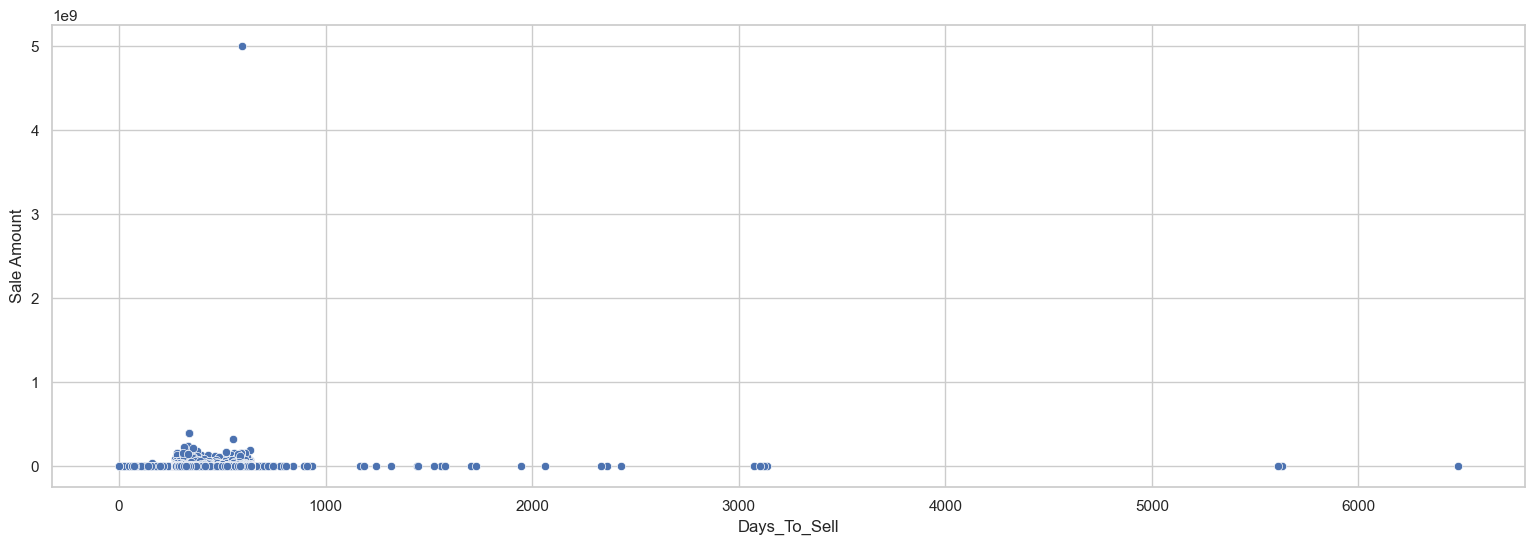

In [243]:
# Import seaborn with alias sns
import seaborn as sns

# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt

# Draw the scatter plot
sns.scatterplot(x = 'Days_To_Sell', y = 'Sale Amount', data = merged_df)

# Show the plot
plt.show()

In [244]:
merged_df['Days_To_Sell'].describe()

count   1,144,645.00
mean          464.43
std           108.87
min             1.00
25%           364.00
50%           478.00
75%           559.00
max         6,481.00
Name: Days_To_Sell, dtype: float64

In [245]:
merged_df[merged_df['Days_To_Sell'] > 5000]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
916971,170177,2017-01-01,1999-04-05,New London,184 PEQUOT AVE 309,"46,690.00","95,000.00",NaN,Condo,Condo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6,481.00",2017,"1,999.00",4.00
937549,173165,2017-01-01,2001-08-01,Shelton,19 BLACKBERRY LA,"390,810.00","635,000.00",NaN,Single Family,Single Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,632.00",2017,"2,001.00",8.00
941335,173202,2017-01-01,2001-08-23,Shelton,12 BOYSENBERRY LA,"427,910.00","558,000.00",NaN,Single Family,Single Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,610.00",2017,"2,001.00",8.00


In [246]:
merged_df['Sale Amount'].describe()

count       1,144,647.00
mean          410,126.74
std         5,042,574.22
min                 0.00
25%           146,000.00
50%           237,363.00
75%           383,034.50
max     5,000,000,000.00
Name: Sale Amount, dtype: float64

In [247]:
merged_df[merged_df['Sale Amount'] == 5000000000]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
63803,20200091,2020-01-01,2021-08-19,Willington,456 TOLLAND TPKE,"2,238,530.00","5,000,000,000.00",NaN,Apartments,NaN,25 - Other,APARTMENTS-COMMERICAL,INCORRECT SALE PRICE,NaN,NaN,NaN,NaN,NaN,596.00,2020,"2,021.00",8.00


In [248]:
# since incorrect sale price i think we can just drop this outlier
merged_df.drop(63585, inplace = True)

In [249]:
# drop prices above 2 million because it can skew the data for training
merged_df = merged_df[merged_df['Sale Amount'] <= 2000000]

## 4. Visualizations
Visual exploration of sale prices by town, residential type,
square footage, and time trends.

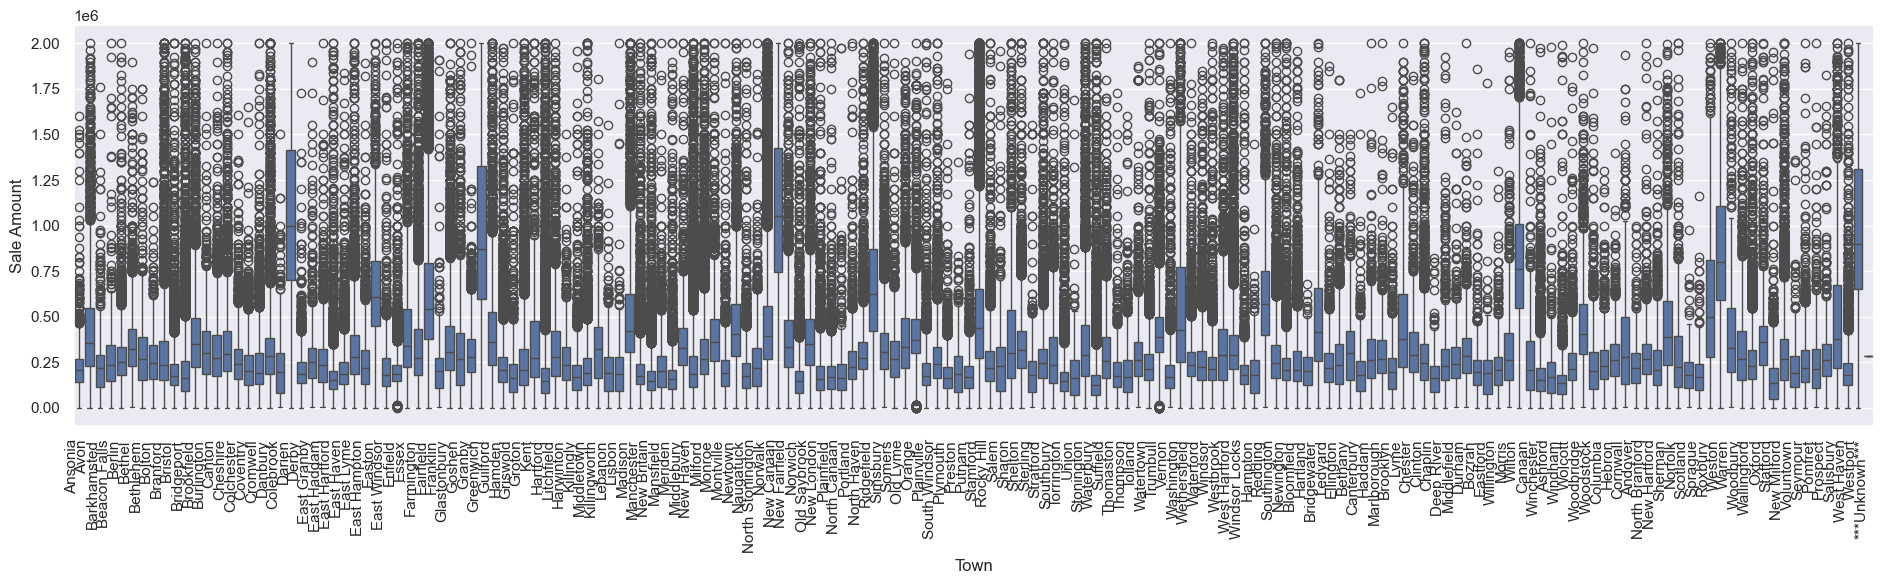

In [250]:
# Set Fig size
sns.set_theme(rc={'figure.figsize':(19, 6)})

sns.boxplot(x = 'Town', y = 'Sale Amount', data = merged_df)

plt.xticks(rotation=90, horizontalalignment='right')

plt.tight_layout()

<Axes: xlabel='Residential Type', ylabel='Sale Amount'>

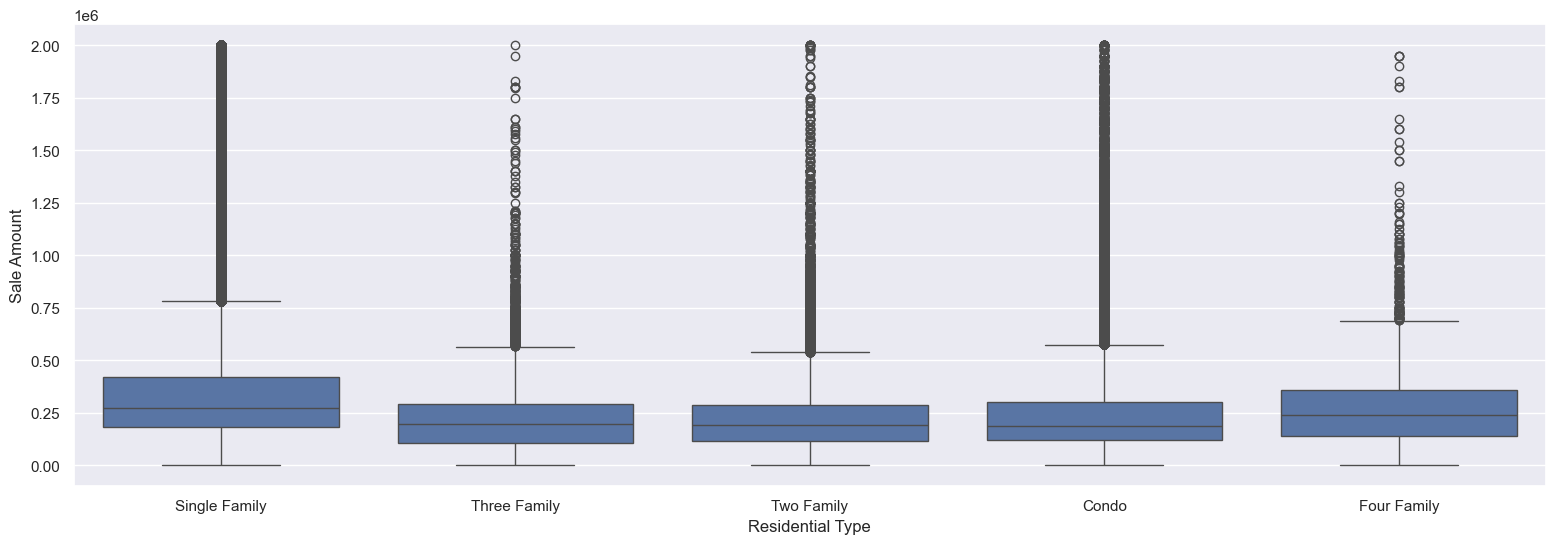

In [251]:
sns.boxplot(x = 'Residential Type', y = 'Sale Amount', data = merged_df)

<Axes: xlabel='Residential Type', ylabel='Sqft'>

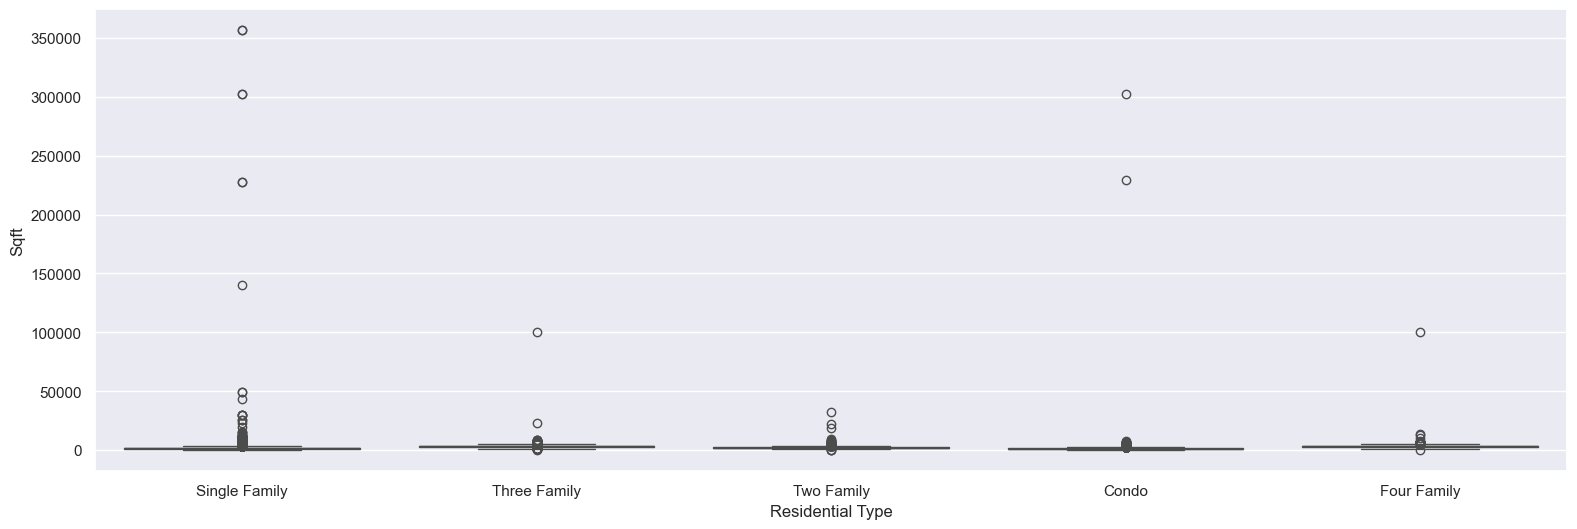

In [252]:
sns.boxplot(x = 'Residential Type', y = 'Sqft', data = merged_df)

<Axes: xlabel='Residential Type', ylabel='Beds'>

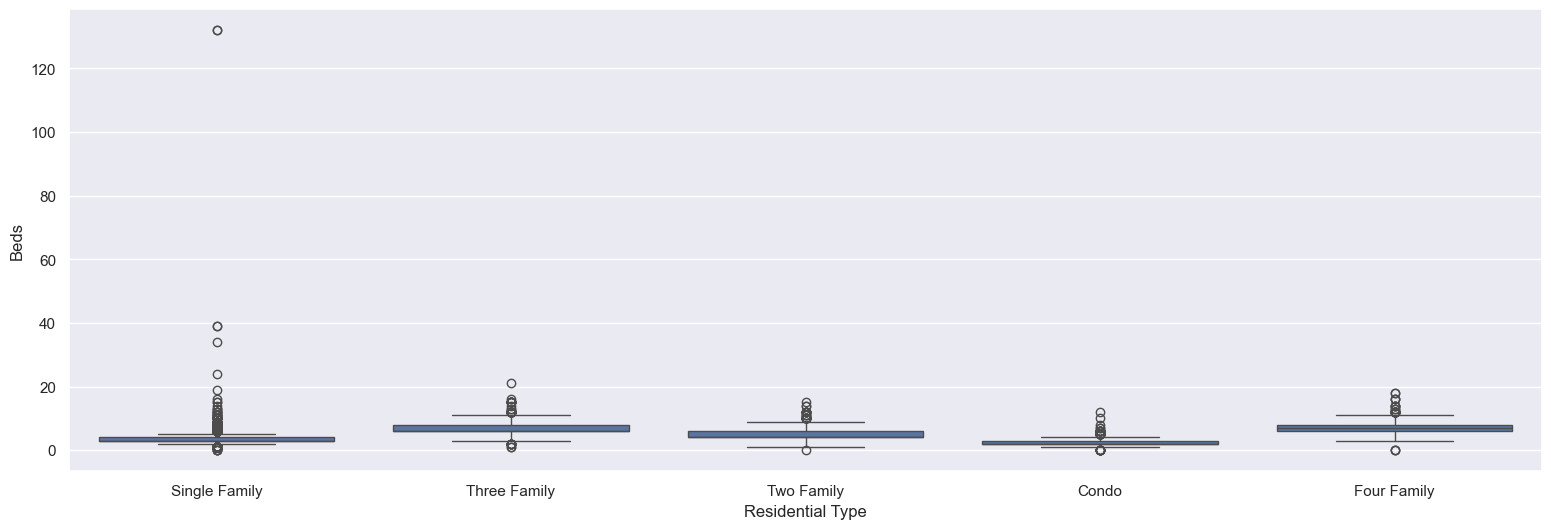

In [253]:
sns.boxplot(x = 'Residential Type', y = 'Beds', data = merged_df)

<Axes: xlabel='Residential Type', ylabel='Garage'>

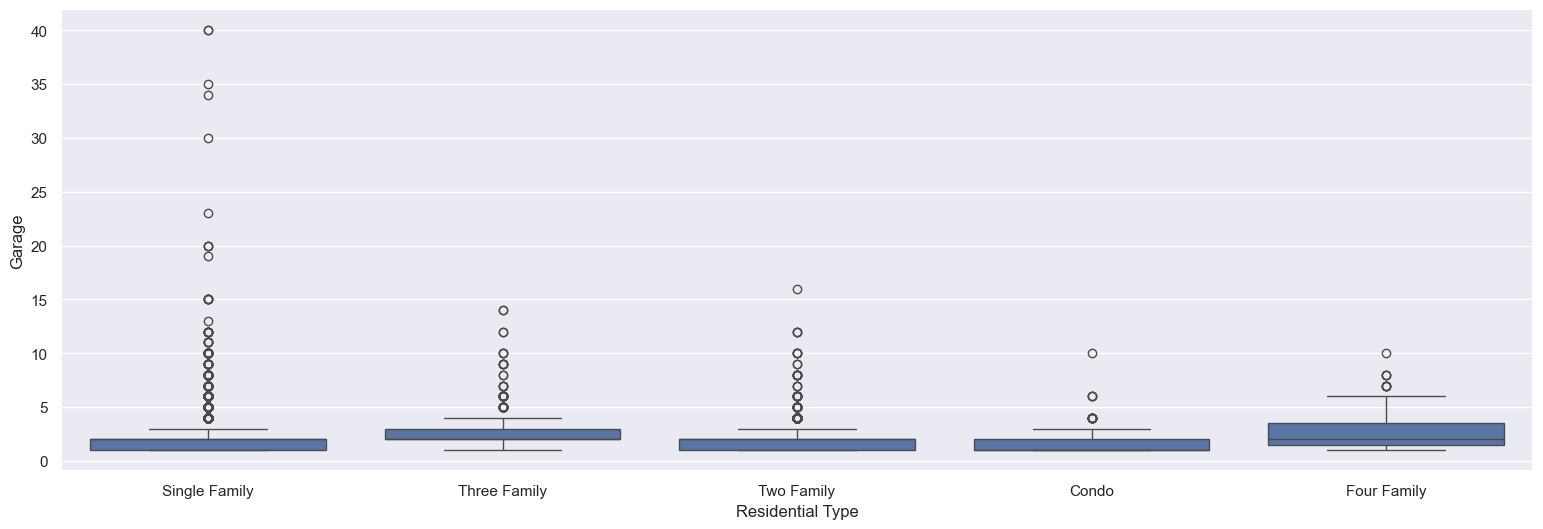

In [254]:
sns.boxplot(x = 'Residential Type', y = 'Garage', data = merged_df)

<Axes: xlabel='prev_list_year', ylabel='Sale Amount'>

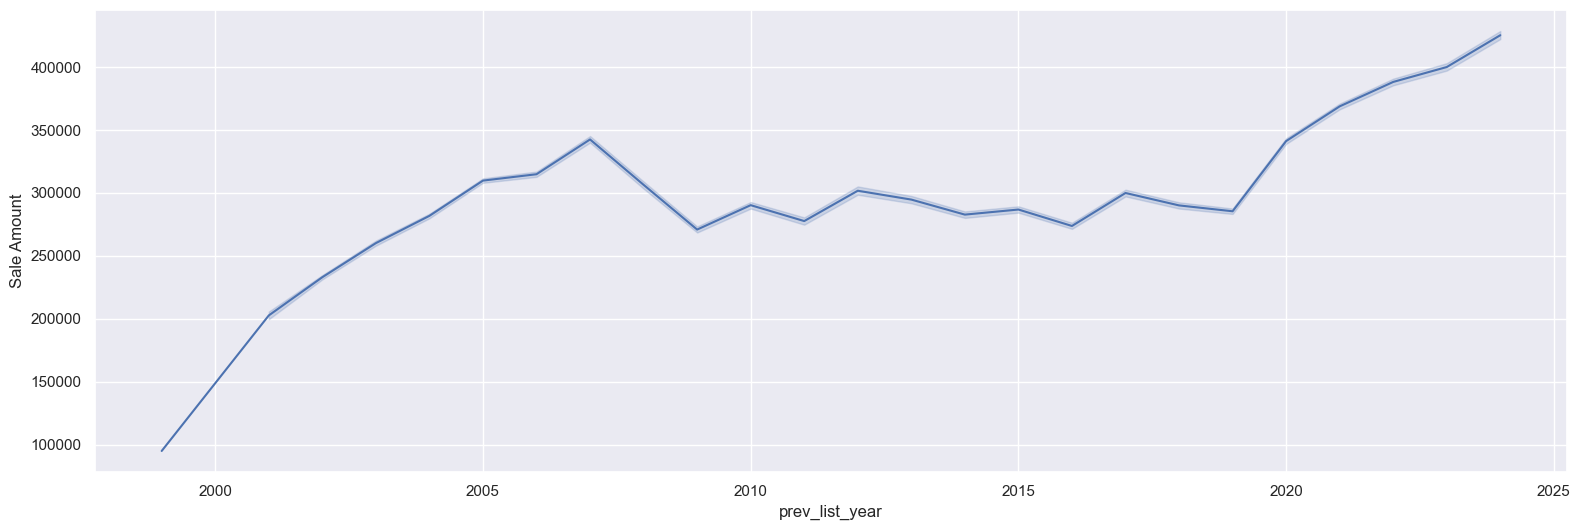

In [255]:
sns.lineplot(x = 'prev_list_year', y = 'Sale Amount',  data = merged_df)

<Axes: xlabel='curr_month_recorded', ylabel='Sale Amount'>

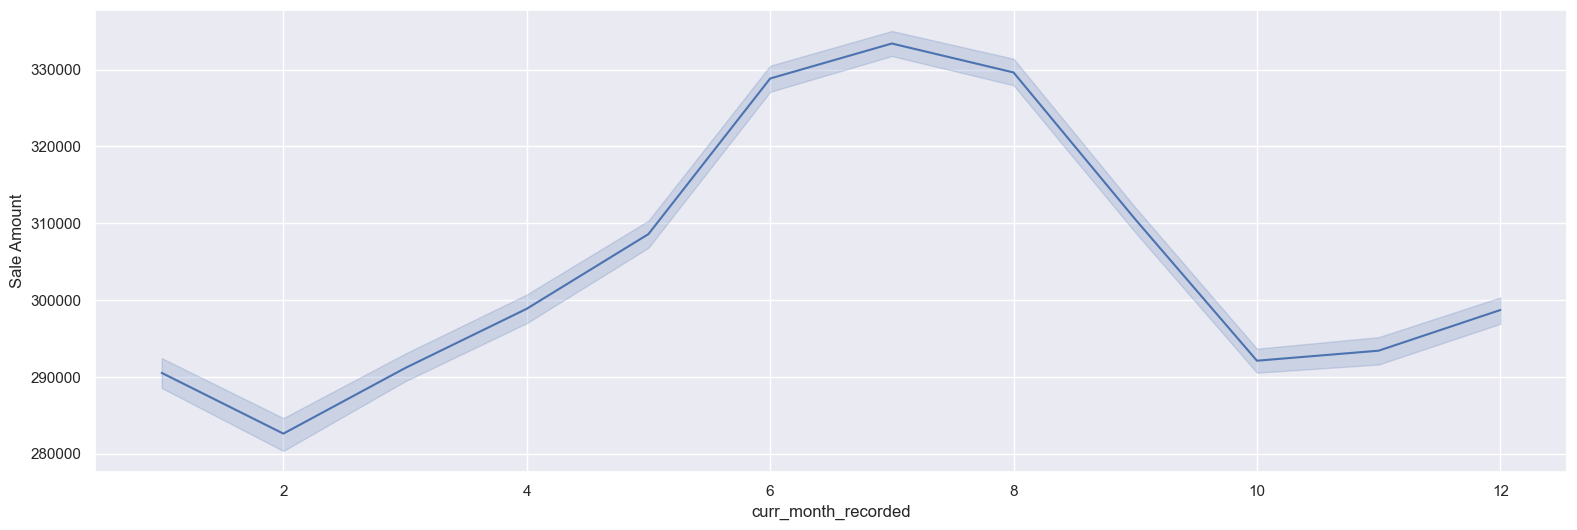

In [256]:
sns.lineplot(x = 'curr_month_recorded', y = 'Sale Amount', data = merged_df)

## 5. Remarks Categorization
Define the RemarksProcessor class and use it to normalize and
group OPM remarks, Assessor remarks, and Non Use Codes into
meaningful categories for modeling.

In [257]:
# we should look for all OPM remarks that include the top 10 values in value_counts
# as well as drop the ones that 'NOT A VALID SALE PER TOWN SITE'

# create function to look for specific remarks in the column
def look_for_remark_index(pattern):
    matching_indices = []

    for idx, value in enumerate(merged_df['OPM remarks']):
        if isinstance(value, str) and re.search(pattern, value):
            matching_indices.append(idx)

    return matching_indices


In [258]:
good_sale_remark = look_for_remark_index(r'GOOD\sSALE\sPER\sMLS.*')
len(good_sale_remark)

1263

In [259]:
pattern = r'GOOD\sSALE\sPER\sMLS.*'

for i in df['OPM remarks']:
    if isinstance(i, str):
        print(re.findall(pattern, i))

[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
['GOOD SALE PER MLS - SOLD OVER ASKING']
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
['GOOD SALE PER MLS']
['GOOD SALE PER MLS']
['GOOD SALE PER MLS']
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
[]
['GOOD SALE PER MLS']
['GOOD SALE PER MLS']
[]
[]
[]
[]
[]
['GOOD SALE PER MLS - 90 DAYS ON MARKET AND SOLD FOR ASKING']
[]
[]
[]
[]
['GOOD SALE PER MLS

In [260]:
# convert all Good Sale remarks to the same remark
pattern = r'GOOD\sSALE\sPER\sMLS.*'
merged_df['OPM remarks'] = merged_df['OPM remarks'].apply(
    lambda x: "GOOD SALE PER MLS" if isinstance(x, str) and re.search(pattern, x, re.IGNORECASE) else x
)



In [261]:
merged_df['OPM remarks'].value_counts()

OPM remarks
GOOD SALE PER MLS                                                                   1263
NO MLS                                                                               675
TOTAL RENOVATION PER MLS                                                             666
NEW CONSTRUCTION                                                                     472
SHORT SALE PER MLS                                                                   369
                                                                                    ... 
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231                                        1
TOTAL RENOVATION PER MLS - C.O. 12/4/2023                                              1
TOTAL RENOVATION PER MLS - SOLD BY PARTIAL INTEREST - TWO DEEDS OF $217,000 EACH       1
TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #230104                                   1
PER MLS CLOSING PRICE = $675,000                                                       1
Name: cou

In [262]:
import re
import pandas as pd

class RemarksProcessor:
    def __init__(self, df, column='OPM remarks'):
        """
        Initialize the RemarksProcessor with a DataFrame and column to operate on.
        """
        self.df = df.copy()
        self.column = column

    def look_for_remark_index(self, pattern, flags=re.IGNORECASE):
        """
        Return indices of rows where the pattern is found in the column.
        """
        matching_indices = []
        for idx, value in enumerate(self.df[self.column]):
            if isinstance(value, str) and re.search(pattern, value, flags):
                matching_indices.append(idx)
        return matching_indices

    def extract_matches(self, pattern, flags=re.IGNORECASE):
        """
        Return a list of all regex full matches per row in the column.
        If no match is found, return an empty list for that row.
        """
        matches = []
        for value in self.df[self.column]:
            if isinstance(value, str):
                found = re.findall(pattern, value, flags)
                if found:
                    matches.append(found)  # list of matches
                else:
                    matches.append([])     # no match
            else:
                matches.append([])
        return matches


    def normalize_remarks(self, pattern, replacement=None, inplace=True):
        """
        Normalize remarks using either a single pattern or a dict of category labels and patterns.
        """

        def replace_single(remark):
            if isinstance(remark, str) and re.search(pattern, remark, re.IGNORECASE):
                return replacement
            return remark

        def replace_multiple(remark):
            if not isinstance(remark, str):
                return remark
            for label, pat in pattern.items():
                if re.search(pat, remark, re.IGNORECASE):
                    return label
            return remark  # no match

        # Determine which logic to use
        if isinstance(pattern, dict):
            updated = self.df[self.column].apply(replace_multiple)
        elif isinstance(pattern, str) and isinstance(replacement, str):
            updated = self.df[self.column].apply(replace_single)
        else:
            raise ValueError("Invalid inputs: provide either a (str, str) or a dict.")

        if inplace:
            self.df[self.column] = updated
            return self.df
        else:
            return updated

    def print_matches(self, pattern, flags=re.IGNORECASE):
        """
        Print all matches found in the column using the regex pattern.
        """
        for value in self.df[self.column]:
            if isinstance(value, str):
                found = re.findall(pattern, value, flags)
                if found:
                    print(found)


In [263]:
# looking through all remarks that point to another remark

# Initialize processor
processor = RemarksProcessor(merged_df)

# Print all matches of a pattern
processor.print_matches(r'[A-Z\s]+-\s[A-Z\s]+#\d+')

['DUPLICATE ENTRY - ALSO SEE #211007']
['RELOCATION - SEE #21092']
['TWO SALES SAME DAY - ALSO SEE  #211893']
['TWO SALES IN ONE DAY - SEE #210295']
['DUPLICATE ENTRY - ALSO SEE #211006']
['FIRST FLOOR TOTAL RENOVATION - SEE PREVIOUS SALE #210345']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210607']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210862']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210198']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210080']
['DUPLICATE ENTRY - ALSO SEE #211176']
['DUPLICATE ENTRY - ALSO SEE #210855']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210020']
[' SALES ON SAME DAY - ALSO SEE #210889']
['RENOVATED UNIT PER MLS - SEE PREVIOUS SALE #211367']
[' UNITS IN COMPLEX IN BULK SALE - SEE SALE #210014']
['NEW CONSTRUCTION - ALSO SEE #21156']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210084']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210100']
['ND SALE SAME DAY - ALSO SEE #211187']
['RENOVATED PER MLS - SEE PREVIOUS SALE #210

In [264]:
# looking for remarks that say are duplicates or the same as others
processor.print_matches(r'.*(DUPLICATE|SAME).*')


['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['SAME']
['SAME']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['SAME']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['DUPLICATE']
['SAME']
['DUPLICATE']
['SAME']
['DUPLICATE']
['SAME']
['DUPLICATE']
['SAME']
['DUPLICATE']
['SAME']
['SAME']
['DUPLICATE']
['DUPLICATE']
['S

In [265]:
# Extract matches into a list
matches = processor.extract_matches(r'.*(DUPLICATE|SAME).*')
# Print full remarks + match for context
for remark, match in zip(processor.df['OPM remarks'], matches):
    if match:  # not empty
        print(f"Match: {match} → Remark: {remark}")

Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #211007
Match: ['SAME'] → Remark: TWO SALES SAME DAY - ALSO SEE  #211893
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #211006
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #211176
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #210855
Match: ['SAME'] → Remark: ALSO SEE SAME DAY SALE #210395
Match: ['SAME'] → Remark: 2 SALES ON SAME DAY - ALSO SEE #210889
Match: ['SAME'] → Remark: 2ND SALE SAME DAY - ALSO SEE #211187
Match: ['SAME'] → Remark: PRINCIPAL OF GRANTEE LLC HAS SAME LAST NAME AS GRANTOR
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #200044
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #200056
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #200325
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #200092
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #201316
Match: ['DUPLICATE'] → Remark: DUPLICATE ENTRY - ALSO SEE #200323
Match: ['

In [266]:
# dont need to include 'SAME' as a duplicate value, not enough data points to consider significant
indices = processor.look_for_remark_index(r"DUPLICATE\s\w+")
print(indices)

[441, 780, 1352, 1410, 5995, 6455, 6520, 6636, 10906, 11153, 17560, 17578, 18545, 21577, 22793, 22924, 23013, 25495, 28257, 28713, 28874, 28956, 29139, 30245, 31236, 33211, 33212, 34046, 34615, 34786, 35671, 36780, 37111, 37227, 39163, 39393, 40558, 41036, 41555, 42467, 43922, 45255, 45257, 46934, 48614, 50623, 51698, 52598, 53265, 53901, 53902, 55261, 56324, 63979, 65661, 69302, 71860, 73588, 75081, 75865, 76389, 79549, 82068, 84005, 84029, 84526, 84805, 85223, 85663, 85711, 86321, 86543, 87344, 87972, 88550, 92438, 93844, 95222, 96650, 96834, 96896, 97568, 100926, 101142, 102589, 102703, 107402, 107412, 109289, 113987, 114468, 117485, 119460, 821151, 843402, 845309, 847471, 848937, 849574, 849818, 850261, 850414, 852990, 858161, 858892, 861198, 861509, 865493, 865917, 867858, 868223, 870343, 872468, 873684, 873951, 877334, 879998, 884436, 884919, 885372, 886861, 887140, 891343, 893628, 896638, 896775, 900324, 900845, 901084, 903041, 903594, 907723, 908046, 908464, 909134, 909722, 910

In [267]:
print(indices)

[441, 780, 1352, 1410, 5995, 6455, 6520, 6636, 10906, 11153, 17560, 17578, 18545, 21577, 22793, 22924, 23013, 25495, 28257, 28713, 28874, 28956, 29139, 30245, 31236, 33211, 33212, 34046, 34615, 34786, 35671, 36780, 37111, 37227, 39163, 39393, 40558, 41036, 41555, 42467, 43922, 45255, 45257, 46934, 48614, 50623, 51698, 52598, 53265, 53901, 53902, 55261, 56324, 63979, 65661, 69302, 71860, 73588, 75081, 75865, 76389, 79549, 82068, 84005, 84029, 84526, 84805, 85223, 85663, 85711, 86321, 86543, 87344, 87972, 88550, 92438, 93844, 95222, 96650, 96834, 96896, 97568, 100926, 101142, 102589, 102703, 107402, 107412, 109289, 113987, 114468, 117485, 119460, 821151, 843402, 845309, 847471, 848937, 849574, 849818, 850261, 850414, 852990, 858161, 858892, 861198, 861509, 865493, 865917, 867858, 868223, 870343, 872468, 873684, 873951, 877334, 879998, 884436, 884919, 885372, 886861, 887140, 891343, 893628, 896638, 896775, 900324, 900845, 901084, 903041, 903594, 907723, 908046, 908464, 909134, 909722, 910

In [268]:
# Drop Duplicates
cleaned_df = merged_df.copy()
pattern = r"DUPLICATE\s\w+"  # base pattern, can be expanded
mask = cleaned_df['OPM remarks'].str.contains(pattern, case=False, na=False)
cleaned_df = cleaned_df[~mask]

In [269]:
# make sure it got dropped
processor = RemarksProcessor(cleaned_df)
processor.print_matches(r"DUPLICATE\s\w+")

In [270]:
processor.print_matches(r'NOT\s+A\s+VALID\s+SALE')

['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID SALE']
['NOT A VALID

In [271]:
# Drop NOT A VALID SALE rows
pattern = r'NOT\s+A\s+VALID\s+SALE'  # base pattern, can be expanded
mask = cleaned_df['OPM remarks'].str.contains(pattern, case=False, na=False)
cleaned_df = cleaned_df[~mask]


In [272]:
cleaned_df['OPM remarks'].value_counts()[0:40]


OPM remarks
GOOD SALE PER MLS                            1263
NO MLS                                        675
TOTAL RENOVATION PER MLS                      666
NEW CONSTRUCTION                              472
SHORT SALE PER MLS                            369
ESTATE SALE                                   341
PURCHASE OF A FORECLOSED PROPERTY             277
TOTAL REMODEL PER MLS                         198
MOBILE HOME                                   145
BELOW MARKET                                  141
COMPLETELY RENOVATED PER MLS                  120
RENOVATED PER MLS                              89
BANK OWNED PER MLS                             89
RENOVATIONS PER MLS                            87
SALE OF A FORECLOSED PROPERTY                  78
BANK SALE PER MLS                              76
FORECLOSURE PER TOWN SITE                      76
BANK SALE PER TOWN SITE                        63
GOOD SALE PER  MLS                             59
RATIO                                 

## Categorizing Sale Remarks

### NO MLS

In [273]:
# Initialize processor
processor = RemarksProcessor(cleaned_df)

# Print all matches of a pattern
processor.print_matches(r'NO MLS.*')


['NO MLS']
['NO MLS - GRANTEE PREVIOUSLY PURCHAED 44 UNITS IN COMPLEX IN BULK SALE - SEE SALE #210014']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS.']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS. RAISED RANCH WITH NO FINISHED BASEMENT AREA ON FIELD CARD.']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS - SOLD TO NEIGHBOR ACROSS STREE FROM OWNERS HOUSE']
['NO MLS']
['NO MLS']
['NO MLS']
['NO MLS']
['NO

In [274]:
# Get matching row indices
indices = processor.look_for_remark_index(r'NO MLS.*')

len(indices)

793

In [275]:
# Extract matches into a list
matches = processor.extract_matches(r'NO MLS.*')

In [276]:
# Normalize all matching rows
cleaned_df = processor.normalize_remarks(r'NO MLS.*', 'NO MLS')

In [277]:
cleaned_df['OPM remarks'].value_counts()

OPM remarks
GOOD SALE PER MLS                                                                   1263
NO MLS                                                                               793
TOTAL RENOVATION PER MLS                                                             666
NEW CONSTRUCTION                                                                     472
SHORT SALE PER MLS                                                                   369
                                                                                    ... 
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231                                        1
TOTAL RENOVATION PER MLS - C.O. 12/4/2023                                              1
TOTAL RENOVATION PER MLS - SOLD BY PARTIAL INTEREST - TWO DEEDS OF $217,000 EACH       1
TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #230104                                   1
PER MLS CLOSING PRICE = $675,000                                                       1
Name: cou

### TOTAL RENOVATION PER MLS 

In [278]:
# Initialize processor
processor = RemarksProcessor(cleaned_df)

# Print all matches of a pattern
processor.print_matches(r'TOTAL RENOVATION PER MLS.*')

['TOTAL RENOVATION PER MLS']
['TOTAL RENOVATION PER MLS']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210607']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210862']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210198']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210080']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210020']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210084']
['TOTAL RENOVATION PER MLS']
['TOTAL RENOVATION PER MLS']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210100']
['TOTAL RENOVATION PER MLS']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210691']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210063']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210100']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210030']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210445']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210563']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #210007']
['TOTAL RENOVATION PER MLS - SEE PREVIOUS SALE #200023']


In [279]:
# Get matching row indices
indices = processor.look_for_remark_index(r'TOTAL RENOVATION PER MLS.*')

len(indices)

2471

In [280]:
# Extract matches into a list
matches = processor.extract_matches(r'TOTAL RENOVATION PER MLS.*')

In [281]:
# Normalize all matching rows
cleaned_df = processor.normalize_remarks(r'TOTAL RENOVATION PER MLS.*', 'TOTAL RENOVATION PER MLS')

In [282]:
cleaned_df['OPM remarks'].value_counts()

OPM remarks
TOTAL RENOVATION PER MLS                              2471
GOOD SALE PER MLS                                     1263
NO MLS                                                 793
NEW CONSTRUCTION                                       472
SHORT SALE PER MLS                                     369
                                                      ... 
SEE #2300039                                             1
PART OF LAND IN CLINTON PER MLS                          1
RENOVATED UNIT PER MLS - SEE PREVIOUS SALE #230544       1
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231          1
PER MLS CLOSING PRICE = $675,000                         1
Name: count, Length: 5085, dtype: int64

### NEW CONSTRUCTION  

In [283]:
# Initialize processor
processor = RemarksProcessor(cleaned_df)

# Print all matches of a pattern
processor.print_matches(r'NEW CONSTRUCTION.*')

['NEW CONSTRUCTION']
['NEW CONSTRUCTION - ALSO SEE #21156']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION - CO 2/22/2021']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION - CO 12/30/2020']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION - CO 2/22/2021']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION - CO 6/25/2021']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION SOLD AS IS WITH ALL APPROVALS IN PLACE - ALSO SEE #200373']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['NEW CONSTRUCTION']
['

In [284]:
# Get matching row indices
indices = processor.look_for_remark_index(r'NEW CONSTRUCTION.*')

len(indices)

590

In [285]:
# Extract matches into a list
matches = processor.extract_matches(r'NEW CONSTRUCTION.*')

In [286]:
# Normalize all matching rows
cleaned_df = processor.normalize_remarks(r'NEW CONSTRUCTION.*', 'NEW CONSTRUCTION')

In [287]:
cleaned_df['OPM remarks'].value_counts()

OPM remarks
TOTAL RENOVATION PER MLS                              2471
GOOD SALE PER MLS                                     1263
NO MLS                                                 793
NEW CONSTRUCTION                                       590
SHORT SALE PER MLS                                     369
                                                      ... 
SEE #2300039                                             1
PART OF LAND IN CLINTON PER MLS                          1
RENOVATED UNIT PER MLS - SEE PREVIOUS SALE #230544       1
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231          1
PER MLS CLOSING PRICE = $675,000                         1
Name: count, Length: 4980, dtype: int64

### SHORT SALE PER MLS 

In [288]:
# Initialize processor
processor = RemarksProcessor(cleaned_df)

# Print all matches of a pattern
processor.print_matches(r'SHORT SALE PER MLS.*')

# Get matching row indices
indices = processor.look_for_remark_index(r'SHORT SALE PER MLS.*')

len(indices)

# Extract matches into a list
matches = processor.extract_matches(r'SHORT SALE PER MLS.*')


['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SALE PER MLS']
['SHORT SAL

In [289]:
# Normalize all matching rows
cleaned_df = processor.normalize_remarks(r'SHORT SALE PER MLS.*', 'SHORT SALE PER MLS')
cleaned_df['OPM remarks'].value_counts()

OPM remarks
TOTAL RENOVATION PER MLS                              2471
GOOD SALE PER MLS                                     1263
NO MLS                                                 793
NEW CONSTRUCTION                                       590
SHORT SALE PER MLS                                     383
                                                      ... 
SEE #2300039                                             1
PART OF LAND IN CLINTON PER MLS                          1
RENOVATED UNIT PER MLS - SEE PREVIOUS SALE #230544       1
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231          1
PER MLS CLOSING PRICE = $675,000                         1
Name: count, Length: 4970, dtype: int64

In [290]:
remarks = df['OPM remarks'].value_counts()
remarks_middle = remarks.iloc[5:12]
print(remarks_middle)

OPM remarks
ESTATE SALE                          341
PURCHASE OF A FORECLOSED PROPERTY    277
TOTAL REMODEL PER MLS                197
MOBILE HOME                          145
BELOW MARKET                         141
COMPLETELY RENOVATED PER MLS         119
NOT A VALID SALE PER TOWN SITE        98
Name: count, dtype: int64


### ESTATE SALE

In [291]:
# Initialize processor
processor = RemarksProcessor(cleaned_df)

# Print all matches of a pattern
processor.print_matches(r'ESTATE SALE.*')

# Get matching row indices
indices = processor.look_for_remark_index(r'ESTATE SALE.*')

len(indices)

# Extract matches into a list
matches = processor.extract_matches(r'ESTATE SALE.*')


['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE. PER MLS HOUSE NEEDS EXTENSIVE RENOVATION.']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE - PER MLS NOT AN APPROVED BUILDING LOT']
['ESTATE SALE.']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE PER MLS, SOLD AS IS']
['ESTATE SALE - RESOLD SEPT. 2021 FOR $190,000 WITH MINIMAL WORK DONE.']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE PER MLS, HAS HALF BATH NOT ON FIELD CARD']
['ESTATE SALE PER MLS EXPIRED LISTING']
['ESTATE SALE. HAS 2 FULL BATHS PER MLS.']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE']
['ESTATE SALE - RESOLD 4/20/2021 $65,000 - SEE #200564']
['ESTATE SALE']
['ESTATE SALE BELOW MARKET - SEE RESALE OF REFRESHED HOME #200329']
['ESTATE SALE']
['ESTATE SALE - NEEDS MAJOR RENOVATION PER MLS, PROBABLE TEAR D

In [292]:
# Normalize all matching rows
cleaned_df = processor.normalize_remarks(r'ESTATE SALE.*', 'ESTATE SALE')
cleaned_df['OPM remarks'].value_counts()

OPM remarks
TOTAL RENOVATION PER MLS                              2471
GOOD SALE PER MLS                                     1263
NO MLS                                                 793
NEW CONSTRUCTION                                       590
ESTATE SALE                                            437
                                                      ... 
SEE #2300039                                             1
PART OF LAND IN CLINTON PER MLS                          1
RENOVATED UNIT PER MLS - SEE PREVIOUS SALE #230544       1
RENOVATIONS PER MLS - SEE PREVIOUS SALE #230231          1
PER MLS CLOSING PRICE = $675,000                         1
Name: count, Length: 4881, dtype: int64

In [293]:
cleaned_df['OPM remarks'].value_counts()[0:40]


OPM remarks
TOTAL RENOVATION PER MLS                     2471
GOOD SALE PER MLS                            1263
NO MLS                                        793
NEW CONSTRUCTION                              590
ESTATE SALE                                   437
SHORT SALE PER MLS                            383
PURCHASE OF A FORECLOSED PROPERTY             277
TOTAL REMODEL PER MLS                         198
MOBILE HOME                                   145
BELOW MARKET                                  141
COMPLETELY RENOVATED PER MLS                  120
RENOVATED PER MLS                              89
BANK OWNED PER MLS                             89
RENOVATIONS PER MLS                            87
SALE OF A FORECLOSED PROPERTY                  78
BANK SALE PER MLS                              76
FORECLOSURE PER TOWN SITE                      76
BANK SALE PER TOWN SITE                        63
GOOD SALE PER  MLS                             59
RATIO                                 

# Group OPM Remarks

| Group Name                   | Count |
| ---------------------------- | ----- |
| RENOVATED/REMODELED          | 3111  |
| GOOD SALE                    | 1367  |
| NO MLS                       | 796   |
| NEW / NON-RESIDENTIAL        | 813   |
| FORECLOSURE / BANK SALE      | 1111  |
| ESTATE / FAMILY / RELOCATION | 484   |
| BELOW MARKET / RATIO         | 234   |
| ASSESSMENT / TAX             | 72    |
| DEED / LEGAL                 | 34    |
| MULTI-PARCEL / OTHER         | 43    |


In [294]:
# renovated/remodeled
pattern = r'\b(TOTAL(?:LY)?|COMPLETE(?:LY)?)?\s*(RENOVAT\w+|REMODEL\w+|UPDAT\w+)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "RENOVATED/REMODELED")

In [295]:
cleaned_df['OPM remarks'].value_counts()

OPM remarks
RENOVATED/REMODELED                                                             4552
GOOD SALE PER MLS                                                               1263
NO MLS                                                                           793
NEW CONSTRUCTION                                                                 590
ESTATE SALE                                                                      437
                                                                                ... 
BELOW MARKET - RESOLD 12/19/2023 $300,500 WITH NO IMPROVEMENTS - SEE #230040       1
COMPLETELY REBUILT FROM FOUNDATION UP PER MLS                                      1
SEE #2300039                                                                       1
PART OF LAND IN CLINTON PER MLS                                                    1
PER MLS CLOSING PRICE = $675,000                                                   1
Name: count, Length: 3459, dtype: int64

In [296]:
# Good Sale
pattern =  r'\bGOOD\s+SALE\s+PER\s+(MLS|TOWN\s+SITE)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "GOOD SALE")

In [297]:
# NO MLS
pattern =  r'\bNO\s+MLS\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "NO MLS")

In [298]:
# NEW / NON-RESIDENTIAL
pattern =  r'\b(NEW\s+CONSTRUCTION|MOBILE\s+HOME|COMMERCIAL\s+VACANT\s+LAND|DOCKOMINIUM)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "NEW / NON-RESIDENTIAL")

In [299]:
# FORECLOSURE / BANK SALE
pattern =  r'\b(SHORT\s+SALE|FORECLOS(ED|URE)\s+PROPERTY|BANK\s+(SALE|OWNED)|PURCHASE\s+OF\s+FORECLOS(ED|URE)\s+PROPERTY|SALE\s+OF\s+FORECLOS(ED|URE)\s+PROPERTY)(?:\s+PER\s+(MLS|TOWN\s+SITE))?\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "FORECLOSURE / BANK SALE")

In [300]:
# ESTATE / FAMILY / RELOCATION
pattern =  r'\b(ESTATE\s+SALE|RELOCATION|FAMILY\s+SALE(?:\s+PER\s+TOWN\s+SITE)?)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "ESTATE / FAMILY / RELOCATION")

In [301]:
# BELOW MARKET / RATIO
pattern =  r'\b(BELOW\s+MARKET(\s*-\s*RATIO)?|RATIO)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "BELOW MARKET / RATIO")

In [302]:
# ASSESSMENT / TAX
pattern =  r'\b(ASSESS(ED|MENT)?(\s+INCREASE\s+AFTER\s+SALE|ED\s+AS\s+UNBUILDABLE)?)\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "ASSESSMENT / TAX")

In [303]:
# DEED / LEGAL
pattern =  r'\bQUIT\s+CLAIM\s+DEED\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "DEED / LEGAL")

In [304]:
# MULTI-PARCEL / OTHER
pattern =  r'\b(MULTIPLE\s+)?PARCEL\s+SALE\b.*'
indices = processor.look_for_remark_index(pattern)
matches = processor.extract_matches(pattern)
cleaned_df = processor.normalize_remarks(pattern, "MULTI-PARCEL / OTHER")

In [305]:
cleaned_df['OPM remarks'].value_counts()

OPM remarks
RENOVATED/REMODELED                              4552
GOOD SALE                                        1349
FORECLOSURE / BANK SALE                          1117
NEW / NON-RESIDENTIAL                             840
NO MLS                                            793
                                                 ... 
SOLD WITH #14 WATERBURY RD - SEE #230093            1
COMPLETELY REBUILT FROM FOUNDATION UP PER MLS       1
SEE #2300039                                        1
PART OF LAND IN CLINTON PER MLS                     1
PER MLS CLOSING PRICE = $675,000                    1
Name: count, Length: 2768, dtype: int64

In [306]:
cleaned_df['OPM remarks'].value_counts()


OPM remarks
RENOVATED/REMODELED                              4552
GOOD SALE                                        1349
FORECLOSURE / BANK SALE                          1117
NEW / NON-RESIDENTIAL                             840
NO MLS                                            793
                                                 ... 
SOLD WITH #14 WATERBURY RD - SEE #230093            1
COMPLETELY REBUILT FROM FOUNDATION UP PER MLS       1
SEE #2300039                                        1
PART OF LAND IN CLINTON PER MLS                     1
PER MLS CLOSING PRICE = $675,000                    1
Name: count, Length: 2768, dtype: int64

In [307]:
df_unique = cleaned_df[cleaned_df['OPM remarks'].isin(df['OPM remarks'].value_counts()[lambda x: x == 1].index)]


In [308]:
list(df_unique['OPM remarks'])

['TWO SALES SAME DAY - ALSO SEE  #211893',
 'PER MLS SALE PRICE = $1,520,000, TWO DEEDS ON TOWN CARD',
 'TWO SALES IN ONE DAY - SEE #210295',
 'PER MLS SLOPING ISSUES ON 2ND FLOOR. ENGINEERS REPORT INCLUDED.',
 'SOLD WITH 2233 CORBIN AVE - #210256',
 'ALSO SEE #210031',
 'PER MLS CLOSING PRICE = $270,000',
 'PER MLS INCLUDES 2ND FULL BATH IN FINISHED BASEMENT',
 'PER MLS HOUSE IN POOR CONDITION. CURRENTLY NO KITCHEN AND ONE BATH IS ROUGH PLUMBING ONLY.',
 'ALSO SEE SAME DAY SALE #210395',
 '2 SALES ON SAME DAY - ALSO SEE #210889',
 'PER MLS SALE PRICE = $490,000 - PART OF PROPERTY IN WOODBRIDGE',
 'PER MLS SALE PRICE = $490,000 - PART OF PROPERTY IN WOODBRIDGE',
 'PER MLS CLOSING PRICE =$322,000',
 'PER MLS PICTURES STRUCTURAL DAMAGE TO INTERIOR. CASH OR REHAB SALE ONLY.',
 '.22 ACRES',
 'PER MLS HOUSE HAS 2.5 BATHS AND FINISHED BASEMENT NOT ON FIELD CARD',
 '2ND SALE SAME DAY - ALSO SEE #211187',
 'STORM DAMAGED HOUSE',
 'NEEDS TOTAL REHAB PER MLS. CASH OFFERS ONLY. SOLD AS IS',
 'PRI

In [309]:
cleaned_df[cleaned_df['OPM remarks'] == 'PER MLS SALE PRICE = $192,000']

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
897647,1700036,2017-01-01,2017-10-20,New Milford,27 TOWN FARM RD,"146,860.00","172,000.00",NaN,Single Family,Single Family,25 - Other,SALES RATIO,"PER MLS SALE PRICE = $192,000",NaN,3.00,1.00,"1,002.00","1,964.00",292.00,2017,"2,017.00",10.00


In [310]:
cleaned_df[cleaned_df['OPM remarks'] == "TOTAL REMODEL PER MLS - SEE PREVIOUS SALE #170101"]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
919272,171022,2017-01-01,2018-05-29,Norwalk,27 ARNOLD LN,"362,800.00","595,000.00",NaN,Single Family,Single Family,07 - Change in Property,6-28-16-0,TOTAL REMODEL PER MLS - SEE PREVIOUS SALE #170101,NaN,3.00,1.00,"1,260.00","1,956.00",513.00,2017,"2,018.00",5.00


In [311]:
cleaned_df[(cleaned_df['Serial Number'] == 170101) & (cleaned_df['Town'] == 'Norwalk')]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded


In [312]:
cleaned_df['OPM remarks'].value_counts()[0:12]

OPM remarks
RENOVATED/REMODELED             4552
GOOD SALE                       1349
FORECLOSURE / BANK SALE         1117
NEW / NON-RESIDENTIAL            840
NO MLS                           793
ESTATE / FAMILY / RELOCATION     580
BELOW MARKET / RATIO             444
ASSESSMENT / TAX                 412
TOTAL REMODEL PER MLS            198
FORECLOSURE PER TOWN SITE         76
MULTI-PARCEL / OTHER              51
DEED / LEGAL                      35
Name: count, dtype: int64

## What types of sales are most likely to be discounted or below market value?

In [313]:
# Use your normalized OPM remarks categories (e.g. "FORECLOSURE", "ESTATE SALE", "GOOD SALE", "INVALID SALE")

#Compare average or median sale prices per square foot by category

#Flag patterns like "FORECLOSURE" sales averaging 20% below market

In [314]:
cleaned_df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
0,2020177,2020-01-01,2021-04-14,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",NaN,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014),3.00,NaN,"2,004.00","1,900.00",469.00,2020,"2,021.00",4.00
1,2020225,2020-01-01,2021-05-26,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",NaN,Residential,Three Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,511.00,2020,"2,021.00",5.00
2,2020348,2020-01-01,2021-09-13,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",NaN,Commercial,NaN,NaN,NaN,NaN,NaN,1.00,NaN,"1,856.00","1,900.00",621.00,2020,"2,021.00",9.00
3,2020090,2020-01-01,2020-12-14,Ansonia,57 PLATT ST,"127,400.00","202,500.00",NaN,Residential,Two Family,NaN,NaN,NaN,NaN,6.00,NaN,"3,102.00","1,939.00",348.00,2020,"2,020.00",12.00
4,210288,2021-01-01,2022-06-20,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",NaN,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988),NaN,NaN,NaN,NaN,535.00,2021,"2,022.00",6.00


In [315]:
# Step 1: Get top 12 most common OPM remarks
top12_remarks = cleaned_df['OPM remarks'].value_counts().head(12).index

# Step 2: Filter DataFrame to just those remarks
filtered_df = cleaned_df[cleaned_df['OPM remarks'].isin(top12_remarks)]

# Step 3: Group and compute stats only for those
sale_stats = (
    filtered_df
    .groupby('OPM remarks')['Sale Amount']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending = False)
    .round(0)
)


In [316]:
sale_stats.head(12)

,count,mean,median
OPM remarks,,,
NEW / NON-RESIDENTIAL,840,"382,574.00","370,063.00"
ASSESSMENT / TAX,412,"327,928.00","253,250.00"
RENOVATED/REMODELED,4552,"312,547.00","275,000.00"
GOOD SALE,1349,"285,306.00","220,000.00"
TOTAL REMODEL PER MLS,198,"251,442.00","241,400.00"
ESTATE / FAMILY / RELOCATION,580,"250,584.00","190,750.00"
MULTI-PARCEL / OTHER,51,"247,510.00","196,875.00"
NO MLS,793,"186,884.00","125,000.00"
FORECLOSURE / BANK SALE,1117,"183,114.00","145,555.00"


In [317]:
# Assuming "GOOD SALE" is the baseline
market_baseline = sale_stats.loc['GOOD SALE', 'mean']

sale_stats['vs_market_%'] = ((sale_stats['mean'] - market_baseline) / market_baseline) * 100

discounted = sale_stats[sale_stats['vs_market_%'] <= 20]

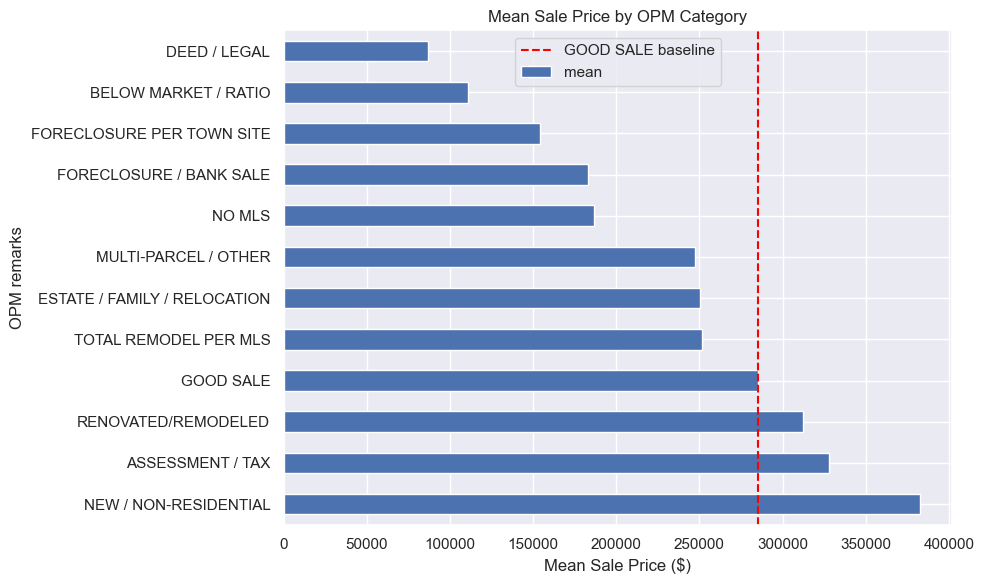

In [318]:
sale_stats['mean'].plot(kind='barh', figsize=(10, 6), title='Mean Sale Price by OPM Category')
plt.axvline(market_baseline, color='red', linestyle='--', label='GOOD SALE baseline')
plt.legend()
plt.xlabel('Mean Sale Price ($)')
plt.tight_layout()
plt.show()


### Summary for this section

 - By grouping transactions by sale type (e.g., “FORECLOSURE”, “ESTATE SALE”, “GOOD SALE”), I found that certain categories consistently underperform. For example, FORECLOSURE sales had a median price 27% below “GOOD SALE” prices — suggesting either distressed selling or possible investment opportunities.

In [319]:
# Check out "see previous sale"
processor.print_matches(r'\b(?:SEE\s+(?:PREVIOUS\s+)?SALE|ALSO\s+SEE)\s+#\d{5,7}')

['ALSO SEE  #211893']
['ALSO SEE #210031']
['ALSO SEE #210889']
['ALSO SEE #211187']
['ALSO SEE #211379']
['SEE PREVIOUS SALE #2020321']
['ALSO SEE #2000004']
['SEE PREVIOUS SALE #2020112']
['ALSO SEE #200374']
['ALSO SEE #2000004']
['ALSO SEE #200096']
['SEE PREVIOUS SALE #200046']
['SEE PREVIOUS SALE #200057']
['SEE SALE #20085']
['SEE SALE #20085']
['SEE PREVIOUS SALE #200002']
['ALSO SEE #20573']
['ALSO SEE #2000003']
['ALSO SEE #2000003']
['ALSO SEE #2000003']
['SEE SALE #201140']
['ALSO SEE #2000003']
['ALSO SEE #20163']
['ALSO SEE #200373']
['SEE PREVIOUS SALE #2000133']
['SEE PREVIOUS SALE #2000248']
['ALSO SEE #200130']
['SEE PREVIOUS SALE #200013']
['ALSO SEE #200710']
['ALSO SEE #202967']
['ALSO SEE #2000735']
['ALSO SEE #200133']
['ALSO SEE #200132']
['SEE PREVIOUS SALE #200931']
['ALSO SEE #200132']
['ALSO SEE #201470']
['SEE PREVIOUS SALE #200049']
['ALSO SEE #200488']
['SEE PREVIOUS SALE #190469']
['SEE PREVIOUS SALE #200772']
['ALSO SEE #200490']
['ALSO SEE #21038']
['A

In [320]:
matches = processor.extract_matches(r'\b(?:SEE\s+(?:PREVIOUS\s+)?SALE|ALSO\s+SEE)\s+#\d{5,7}')
#matches
# Print full remarks + match for context
for remark, match in zip(processor.df['OPM remarks'], matches):
    if match:  # not empty
        print(f"Match: {match} → Remark: {remark}")

Match: ['ALSO SEE  #211893'] → Remark: TWO SALES SAME DAY - ALSO SEE  #211893
Match: ['ALSO SEE #210031'] → Remark: ALSO SEE #210031
Match: ['ALSO SEE #210889'] → Remark: 2 SALES ON SAME DAY - ALSO SEE #210889
Match: ['ALSO SEE #211187'] → Remark: 2ND SALE SAME DAY - ALSO SEE #211187
Match: ['ALSO SEE #211379'] → Remark: SECOND SALE IN ONE WEEK - ALSO SEE #211379
Match: ['SEE PREVIOUS SALE #2020321'] → Remark: COMPLETE REMODEL PER MLS - SEE PREVIOUS SALE #2020321
Match: ['ALSO SEE #2000004'] → Remark: ALSO SEE #200000410
Match: ['SEE PREVIOUS SALE #2020112'] → Remark: COMPLETE REMODEL PER MLS - SEE PREVIOUS SALE #2020112 & 2020113
Match: ['ALSO SEE #200374'] → Remark: ALSO SEE #200374
Match: ['ALSO SEE #2000004'] → Remark: ALSO SEE #200000411
Match: ['ALSO SEE #200096'] → Remark: ALSO SEE #200096
Match: ['SEE PREVIOUS SALE #200046'] → Remark: COMPLETE REMODEL PER MLS - SEE PREVIOUS SALE #200046
Match: ['SEE PREVIOUS SALE #200057'] → Remark: COMPLETE REMODEL PER MLS - SEE PREVIOUS SALE 

In [321]:
processor.look_for_remark_index(r'\b(?:SEE\s+(?:PREVIOUS\s+)?SALE|ALSO\s+SEE)\s+#\d{5,7}')

[613,
 957,
 1587,
 2446,
 3134,
 5603,
 6021,
 6229,
 6433,
 7636,
 9212,
 10280,
 10796,
 11263,
 11264,
 14932,
 15256,
 15594,
 15595,
 15596,
 16203,
 20702,
 21879,
 22918,
 23339,
 24946,
 25238,
 26281,
 26403,
 32427,
 33157,
 33915,
 35604,
 37499,
 39941,
 42367,
 43204,
 57394,
 64504,
 66620,
 68304,
 70394,
 70765,
 71687,
 73879,
 75701,
 76925,
 79468,
 80067,
 80859,
 82547,
 83183,
 84258,
 85079,
 86754,
 92714,
 94842,
 97888,
 98984,
 99144,
 103147,
 105351,
 105626,
 106799,
 107822,
 107989,
 111185,
 843519,
 845193,
 847799,
 852283,
 853808,
 854478,
 861871,
 866707,
 867703,
 867761,
 867972,
 868180,
 868225,
 868894,
 869058,
 869704,
 869767,
 869888,
 870152,
 871116,
 871437,
 871825,
 871960,
 872391,
 872497,
 873113,
 873178,
 873677,
 873770,
 873852,
 873865,
 873903,
 874023,
 874200,
 874787,
 874901,
 876249,
 877458,
 878167,
 878472,
 878684,
 879363,
 879654,
 879847,
 880302,
 880419,
 880482,
 881565,
 882014,
 882740,
 883012,
 885082,
 8

In [322]:
cleaned_df[cleaned_df['OPM remarks'] == "TOTAL REMODEL PER MLS - SEE PREVIOUS SALE #180026"]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
986292,180141,2018-01-01,2019-04-01,Ledyard,10 BUTTERCUP LN,"193,830.00","296,900.00",NaN,Single Family,Single Family,07 - Change in Property,NaN,TOTAL REMODEL PER MLS - SEE PREVIOUS SALE #180026,POINT (-72.05788 41.46548),NaN,NaN,NaN,NaN,455.00,2018,"2,019.00",4.00


In [323]:
cleaned_df[(cleaned_df['Serial Number'] == 180026) & (cleaned_df['Town'] == 'Ledyard')]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
980012,180026,2018-01-01,2018-10-17,Ledyard,10 BUTTERCUP LN,"193,830.00","124,500.00",NaN,Single Family,Single Family,25 - Other,ESTATE SALE,NaN,POINT (-72.05788 41.46548),NaN,NaN,NaN,NaN,289.00,2018,"2,018.00",10.00


In [324]:
cleaned_df[cleaned_df['Address'] == "56 LEDYARD ST"]

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
821039,150113,2015-01-01,2016-01-15,New London,56 LEDYARD ST,"90,510.00","72,000.00",NaN,Single Family,Single Family,16 - Charitable Group,SALE OF FORECLOSED PROPERTY,NaN,POINT (-72.11106 41.35828),3.00,NaN,"1,203.00","1,940.00",379.00,2015,"2,016.00",1.00
923290,170116,2017-01-01,2018-01-23,New London,56 LEDYARD ST,"103,880.00","150,000.00",NaN,Single Family,Single Family,NaN,NaN,NaN,POINT (-72.11106 41.35828),3.00,NaN,"1,203.00","1,940.00",387.00,2017,"2,018.00",1.00


## Assessor Remarks

In [325]:
cleaned_df['Assessor Remarks'].value_counts()

Assessor Remarks
ESTATE SALE                     5985
SHORT SALE                      2567
BELOW MARKET                    2566
NEW CONSTRUCTION                2515
SALES RATIO                     2228
                                ... 
DECLARAED BUILDABLE                1
70% comp                           1
SOLD WITH GARAGE UNIT F1G          1
DEVELOPERS LOT FOR NEW CONST       1
89 33 512                          1
Name: count, Length: 76685, dtype: int64

In [326]:
processor_assessor = RemarksProcessor(cleaned_df, column='Assessor Remarks')

In [327]:
pattern = (
    r'\bVACANT\b'
    r'|\bINVALID\s+SALE\b'
    r'|\bNOT\s+A\s+VALID\s+SALE\b'
    r'|\bNOT\s+REFLECTIVE\b'
    r'|SALE\s+PRICE\s+IS\s+NOT\s+REFLECTIVE.*'
)

processor_assessor.print_matches(pattern)

['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['Sale price is not reflective of market value for this type of property']
['VACANT']
['Sale price is not reflective of market value for this type of property']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['Sale price is not reflective of market value for this type of property']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['Vacant']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VACANT']
['VAC

In [328]:
matches = processor_assessor.extract_matches(pattern)

# Print full remarks + match for context
for remark, match in zip(processor_assessor.df['Assessor Remarks'], matches):
    if match:  # not empty
        print(f"Match: {match} → Remark: {remark}")

Match: ['VACANT'] → Remark: 9 ACRES VACANT LAND
Match: ['VACANT'] → Remark: VACANT RES
Match: ['VACANT'] → Remark: SALE OF 2 LOTS; SECOND LOT IS VACANT LAND AT 170 HOWARD AVE
Match: ['VACANT'] → Remark: PP TOO LOW, RATIO TOO HIGH VACANT LOT
Match: ['VACANT'] → Remark: LOW SALE BUT FOLLOWS SALES TRENDS IN ANSONIA FOR VACANT LAND
Match: ['VACANT'] → Remark: TWO SEPARATE PARCELS (SINGLE FAMILY AND VACANT LOT)
Match: ['VACANT'] → Remark: PP TOO LOW, RATIO TOO HIGH VACANT LOT
Match: ['Sale price is not reflective of market value for this type of property'] → Remark: Sale price is not reflective of market value for this type of property
Match: ['VACANT'] → Remark: MULTI PARCEL 9 MILLTOWN 355,200 13 MILLTOWN 34,000 VACANT LAND
Match: ['Sale price is not reflective of market value for this type of property'] → Remark: Sale price is not reflective of market value for this type of property
Match: ['VACANT'] → Remark: 1 DEED; 2 PROPERTIES; 136 AUGUR ST - VACANT LAND
Match: ['VACANT'] → Remark: PP

In [329]:
#drop vacant lot and invalid prices
mask = cleaned_df['Assessor Remarks'].str.contains(pattern, case=False, na=False)
cleaned_df = cleaned_df[~mask]
# Reinitialize processor on updated cleaned_df
processor_assessor = RemarksProcessor(cleaned_df, column='Assessor Remarks')

In [330]:
cleaned_df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
0,2020177,2020-01-01,2021-04-14,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",NaN,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014),3.00,NaN,"2,004.00","1,900.00",469.00,2020,"2,021.00",4.00
1,2020225,2020-01-01,2021-05-26,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",NaN,Residential,Three Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,511.00,2020,"2,021.00",5.00
2,2020348,2020-01-01,2021-09-13,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",NaN,Commercial,NaN,NaN,NaN,NaN,NaN,1.00,NaN,"1,856.00","1,900.00",621.00,2020,"2,021.00",9.00
3,2020090,2020-01-01,2020-12-14,Ansonia,57 PLATT ST,"127,400.00","202,500.00",NaN,Residential,Two Family,NaN,NaN,NaN,NaN,6.00,NaN,"3,102.00","1,939.00",348.00,2020,"2,020.00",12.00
4,210288,2021-01-01,2022-06-20,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",NaN,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988),NaN,NaN,NaN,NaN,535.00,2021,"2,022.00",6.00


In [331]:
df_unique_assessor = cleaned_df[cleaned_df['Assessor Remarks'].isin(cleaned_df['Assessor Remarks'].value_counts()[lambda x: x == 1].index)]

In [332]:
df_unique_assessor['Assessor Remarks']

7          2003 COLONIAL, 2140 SFLA, 2.99 AC
45                                     R/C/8
48                              BAA OVERRIDE
50                                 L15008-61
55                                 C15019-19
                         ...                
1144597                  DECLARAED BUILDABLE
1144600                             70% comp
1144604            SOLD WITH GARAGE UNIT F1G
1144645         DEVELOPERS LOT FOR NEW CONST
1144646                            89 33 512
Name: Assessor Remarks, Length: 64650, dtype: str

## Create categories for Assessor Remarks

In [333]:
cleaned_df['Assessor Remarks'].value_counts()[0:40]

Assessor Remarks
ESTATE SALE                                                                    5985
SHORT SALE                                                                     2567
BELOW MARKET                                                                   2566
NEW CONSTRUCTION                                                               2515
SALES RATIO                                                                    2228
FORECLOSURE                                                                    1921
MOBILE HOME                                                                    1900
SALE OF FORECLOSED PROPERTY                                                    1697
PRIVATE SALE                                                                   1504
BANK SALE                                                                      1193
qualified sale                                                                 1050
OUT OF FORECLOSURE                                         

In [334]:
assessor_patterns = {
    "Multi-Parcel Foreclosure": (
        r"SALE\s+OF\s+(?:A\s+)?FORCLOSED\s+(?:PROPERTY|PARCELS?)"
        r"|SALE\s+OF\s+(?:A\s+)?FORECLOSED\s+(?:PROPERTY|PARCELS?)"
        r"|MULTI(?:PLE)?\s+PARCEL(?:S| SALE)?.*FORECLOS"
    ),

    "Foreclosure": (
        r"\bFORECLOSURE\b"
        r"|OUT\s+OF\s+FORECLOSURE"
        r"|SALE\s+OF\s+(?:A\s+)?FORCLOSED"
        r"|SALE\s+OF\s+(?:A\s+)?FORECLOSED"
    ),

    "Multi-Parcel": r"\bMULTI(?:PLE)?\s+PARCEL(?:S| SALE)?\b",

    "Bank Sale": r"\bBANK\s+SALE\b|\bBANK\s+OWNED\b",

    "Relocation": r"\bRELOCATION\b",

    "Family Transfer": r"\bFAMILY\s+SALE\b",

    "Renovated": r"\bUPDATE(?:D|S)?\b|\bUPGRADE(?:D|S)?\b|\bRENOVATED\b",

    "Short Sale": r"\bSHORT\s+SALE\b",

    "As-Is Sale": r"\bAS\s+IS\b|\bSOLD\s+AS\s+IS\b",

    "Off-Market": r"\bNOT\s+ON\s+OPEN\s+MARKET\b|\bNOT\s+LISTED\b",

    "Below Market": r"\bBELOW\s+MARKET\b|\bSOLD\s+BELOW\b",

    "Estate Sale": r"\bESTATE\b|\bEXECUTOR'?S?\s+DEED\b"
}


In [335]:
cleaned_df = processor_assessor.normalize_remarks(pattern = assessor_patterns, inplace = True)

In [336]:
cleaned_df['Assessor Remarks'].value_counts()[0:40]

Assessor Remarks
Estate Sale                                                                    13445
Foreclosure                                                                    11020
Below Market                                                                    6326
Short Sale                                                                      4616
Multi-Parcel Foreclosure                                                        4083
NEW CONSTRUCTION                                                                2515
SALES RATIO                                                                     2228
Bank Sale                                                                       2200
Multi-Parcel                                                                    2131
MOBILE HOME                                                                     1900
Relocation                                                                      1600
Family Transfer                                 

## Create categories for NON USE CODE

In [337]:
cleaned_df['Non Use Code'].value_counts()[0:40]

Non Use Code
 25 - Other                          66713
 14 - Foreclosure                    55582
 07 - Change in Property             41263
 08 - Part Interest                  18178
 01 - Family                         15332
7.00                                 13611
 7                                    9857
1.00                                  6761
 10 - A Will                          6166
8.00                                  5410
 28 - Use Assessment                  5274
 06 - Portion of Property             4760
 18 - In Lieu Of Foreclosure          3971
 15 - Government Agency               3557
25.00                                 3461
 1                                    3455
6.00                                  3324
 8                                    3146
 03 - Inter Corporation               3136
14.00                                 3101
 25                                   2947
 24 - Plottage                        2863
 11 - Court Order                     256

In [338]:
nonuse_patterns = {
    "Foreclosure": r"\bFORECLOSURE\b|^14\b|^18\b",
    "Partial Ownership": r"\bPART\s+INTEREST\b|^08\b",
    "Family Transfer": r"\bFAMILY\b|^01\b",
    "Property Adjustment": r"\bCHANGE\s+IN\s+PROPERTY\b|^07\b",
    "Court Sale": r"\bCOURT\s+ORDER\b|^11\b",
    "Estate Transfer": r"\bA\s+WILL\b|\bESTATE\b|^10\b",
    "Special Assessment": r"\bUSE\s+ASSESSMENT\b|^28\b",
    "Gov Transfer": r"\bGOVERNMENT\s+AGENCY\b|^15\b",
    "Land Assembly": r"\bPLOTTAGE\b|^24\b",
    "Tax Sale": r"\bTAX\b|^09\b",
    "Bankruptcy": r"\bBANKRUPTCY\b|^13\b"
}


In [339]:
processor_nuc = RemarksProcessor(cleaned_df, column='Non Use Code')

In [340]:
cleaned_df = processor_nuc.normalize_remarks(pattern = nonuse_patterns, inplace = True)

In [341]:
cleaned_df['Non Use Code'].value_counts()[0:96]

Non Use Code
25 - Other             66713
Foreclosure            60915
Property Adjustment    41263
Partial Ownership      18178
Family Transfer        15335
                       ...  
88                         1
37                         1
34                         1
74                         1
75                         1
Name: count, Length: 96, dtype: int64

In [342]:
#shorten value_counts
shortened_col = cleaned_df['Non Use Code'].value_counts()
val_counts = shortened_col[shortened_col >= 1000].index
cleaned_df['Non Use Code'] = cleaned_df['Non Use Code'].apply(lambda x:x if x in val_counts else "Other")

In [343]:
cleaned_df['Non Use Code'].value_counts()

Non Use Code
 Other                           814718
 25 - Other                       66713
 Foreclosure                      60915
 Property Adjustment              41263
 Partial Ownership                18178
 Family Transfer                  15335
7.00                              13611
 7                                 9857
 Estate Transfer                   6937
1.00                               6761
 Special Assessment                6094
8.00                               5410
 06 - Portion of Property          4760
 Gov Transfer                      3753
 Land Assembly                     3554
25.00                              3461
 1                                 3455
6.00                               3324
 8                                 3146
 03 - Inter Corporation            3136
14.00                              3101
 25                                2947
 Court Sale                        2734
 6                                 2138
 26 - Rehabilitation Deferr

In [344]:
# done with shortening object cols

In [345]:
cleaned_df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
0,2020177,2020-01-01,2021-04-14,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",NaN,Residential,Single Family,Other,NaN,NaN,POINT (-73.06822 41.35014),3.00,NaN,"2,004.00","1,900.00",469.00,2020,"2,021.00",4.00
1,2020225,2020-01-01,2021-05-26,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",NaN,Residential,Three Family,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,511.00,2020,"2,021.00",5.00
2,2020348,2020-01-01,2021-09-13,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",NaN,Commercial,NaN,Other,NaN,NaN,NaN,1.00,NaN,"1,856.00","1,900.00",621.00,2020,"2,021.00",9.00
3,2020090,2020-01-01,2020-12-14,Ansonia,57 PLATT ST,"127,400.00","202,500.00",NaN,Residential,Two Family,Other,NaN,NaN,NaN,6.00,NaN,"3,102.00","1,939.00",348.00,2020,"2,020.00",12.00
4,210288,2021-01-01,2022-06-20,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",NaN,Residential,Condo,Other,NaN,NaN,POINT (-72.879115982 41.773452988),NaN,NaN,NaN,NaN,535.00,2021,"2,022.00",6.00


## Cleanup cleaned_df

In [346]:
#we could probably jsut drop Location and serial number becasue it has the most redundent info, the rest we should take a look at
cleaned_df.drop(['Location', 'Serial Number'], axis = 1, inplace = True)
#also drop sales ration because it missing most of its data
cleaned_df.drop('Sales Ratio', axis = 1, inplace = True)

In [347]:
# Replace NaNs with 'Unknown' in all object (string) columns
for col in cleaned_df.select_dtypes(include='object').columns:
    cleaned_df[col] = cleaned_df[col].fillna('Unknown')


In [348]:
cleaned_df.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
0,2020-01-01,2021-04-14,Ansonia,323 BEAVER ST,"133,000.00","248,400.00",Residential,Single Family,Other,Unknown,Unknown,3.00,NaN,"2,004.00","1,900.00",469.00,2020,"2,021.00",4.00
1,2020-01-01,2021-05-26,Ansonia,152 JACKSON ST,"110,500.00","239,900.00",Residential,Three Family,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,511.00,2020,"2,021.00",5.00
2,2020-01-01,2021-09-13,Ansonia,230 WAKELEE AVE,"150,500.00","325,000.00",Commercial,Unknown,Other,Unknown,Unknown,1.00,NaN,"1,856.00","1,900.00",621.00,2020,"2,021.00",9.00
3,2020-01-01,2020-12-14,Ansonia,57 PLATT ST,"127,400.00","202,500.00",Residential,Two Family,Other,Unknown,Unknown,6.00,NaN,"3,102.00","1,939.00",348.00,2020,"2,020.00",12.00
4,2021-01-01,2022-06-20,Avon,12 BYRON DRIVE,"179,990.00","362,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,535.00,2021,"2,022.00",6.00


In [349]:
cleaned_df.shape

(1119333, 19)

In [350]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 1119333 entries, 0 to 1144646
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   List Year            1119333 non-null  datetime64[us]
 1   Date Recorded        1119331 non-null  datetime64[us]
 2   Town                 1119333 non-null  str           
 3   Address              1119333 non-null  object        
 4   Assessed Value       1119333 non-null  float64       
 5   Sale Amount          1119333 non-null  float64       
 6   Property Type        1119333 non-null  str           
 7   Residential Type     1119333 non-null  str           
 8   Non Use Code         1119333 non-null  object        
 9   Assessor Remarks     1119333 non-null  str           
 10  OPM remarks          1119333 non-null  str           
 11  Beds                 269439 non-null   float64       
 12  Garage               105400 non-null   float64       
 13  Sqft         

## 6. Feature Engineering
Create model-ready features including date components, home age,
luxury flag, flip candidate detection, and town YoY growth.

In [351]:
# Link serial numbers and compare sale dates and price changes
# Show cases where a property sold twice within 12 months for a large profit
cleaned_df_sorted = cleaned_df.sort_values('Date Recorded', ascending=False)

In [352]:
cleaned_df_sorted.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
1127910,2023-01-01,2024-10-02,Putnam,23 MECHANICS ST #101,"32,200.00","80,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00
1132613,2023-01-01,2024-10-02,Putnam,74 PERRY ST #183,"122,200.00","310,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00
1119253,2023-01-01,2024-10-02,East Lyme,138 BOSTON POST RD #7,"209,720.00","464,000.00",Residential,Condo,Property Adjustment,NEW CONSTRUCTION,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00
1126683,2023-01-01,2024-09-30,Newington,290 CEDAR ST,"141,990.00","346,000.00",Residential,Single Family,Other,Unknown,Unknown,3.00,1.00,"1,192.00","1,959.00",638.00,2023,"2,024.00",9.00
1112142,2023-01-01,2024-09-30,Bridgeport,80 CARTRIGHT ST UNIT #8A,"45,030.00","123,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,638.00,2023,"2,024.00",9.00


In [353]:
# Only keep rows where Address + Town are duplicated
# address can be duplicated but are differnt properties if each has their own town
dupes = cleaned_df_sorted[
    cleaned_df_sorted.duplicated(subset=['Address', 'Town'], keep=False)
].copy()

In [354]:
dupes = dupes.sort_values(by=['Address', 'Town', 'Date Recorded'], ascending=[True, True, True])

In [355]:
dupes.head(15)

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
781532,2014-01-01,2015-06-17,Norwalk,0 PINE POINT RD,"56,280.00","110,000.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER CONDO UNIT # 258,Unknown,NaN,NaN,NaN,NaN,532.00,2014,"2,015.00",6.00
793557,2014-01-01,2015-06-25,Norwalk,0 PINE POINT RD,"13,300.00","3,000.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER CONDO UNIT # 182,Unknown,NaN,NaN,NaN,NaN,540.00,2014,"2,015.00",6.00
781960,2014-01-01,2015-07-14,Norwalk,0 PINE POINT RD,"56,280.00","120,000.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER CONDO UNIT # 193,Unknown,NaN,NaN,NaN,NaN,559.00,2014,"2,015.00",7.00
781324,2014-01-01,2015-08-03,Norwalk,0 PINE POINT RD,"56,280.00","105,300.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER - CONDO UNIT # 372,Unknown,NaN,NaN,NaN,NaN,579.00,2014,"2,015.00",8.00
271989,2003-01-01,2004-03-19,Thompson,0 & 12 JOHNSON ST,"83,000.00",1.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,443.00,2003,"2,004.00",3.00
275826,2003-01-01,2004-03-19,Thompson,0 & 12 JOHNSON ST,"83,000.00",1.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,443.00,2003,"2,004.00",3.00
313752,2003-01-01,2004-03-19,Thompson,0 & 12 JOHNSON ST,"83,000.00",1.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,443.00,2003,"2,004.00",3.00
418801,2005-01-01,2006-03-16,Thompson,0 & 12 JOHNSON ST,0.00,"125,000.00",Unknown,Unknown,1,Unknown,Unknown,NaN,NaN,NaN,NaN,439.00,2005,"2,006.00",3.00
215394,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00
257393,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00


In [356]:
# Take the latest 2 sales per property (Address + Town)
dupes_top2 = dupes.groupby(['Address', 'Town']).tail(2).copy()

In [357]:
dupes_top2.head(10)

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded
781960,2014-01-01,2015-07-14,Norwalk,0 PINE POINT RD,"56,280.00","120,000.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER CONDO UNIT # 193,Unknown,NaN,NaN,NaN,NaN,559.00,2014,"2,015.00",7.00
781324,2014-01-01,2015-08-03,Norwalk,0 PINE POINT RD,"56,280.00","105,300.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER - CONDO UNIT # 372,Unknown,NaN,NaN,NaN,NaN,579.00,2014,"2,015.00",8.00
313752,2003-01-01,2004-03-19,Thompson,0 & 12 JOHNSON ST,"83,000.00",1.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,443.00,2003,"2,004.00",3.00
418801,2005-01-01,2006-03-16,Thompson,0 & 12 JOHNSON ST,0.00,"125,000.00",Unknown,Unknown,1,Unknown,Unknown,NaN,NaN,NaN,NaN,439.00,2005,"2,006.00",3.00
215394,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00
257393,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00
647124,2010-01-01,2011-03-28,Newington,0 ALUMNI ROAD,"70,000.00","140,000.00",Unknown,Unknown,Land Assembly,Combining of two or more sites under a single ...,Unknown,NaN,NaN,NaN,NaN,451.00,2010,"2,011.00",3.00
639217,2010-01-01,2011-05-31,Newington,0 ALUMNI ROAD,"63,720.00","82,000.00",Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,515.00,2010,"2,011.00",5.00
1021522,2019-01-01,2020-03-04,Naugatuck,0 ANDREW MOUNTAIN RD,"43,660.00","12,900.00",Unknown,Unknown,25 - Other,Estate Sale,Unknown,NaN,NaN,NaN,NaN,428.00,2019,"2,020.00",3.00
1059019,2022-01-01,2022-12-01,Naugatuck,0 ANDREW MOUNTAIN RD,"92,520.00","165,000.00",Vacant Land,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,334.00,2022,"2,022.00",12.00


In [358]:
dupes_top2.info()

<class 'pandas.DataFrame'>
Index: 414254 entries, 781960 to 371323
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   List Year            414254 non-null  datetime64[us]
 1   Date Recorded        414252 non-null  datetime64[us]
 2   Town                 414254 non-null  str           
 3   Address              414254 non-null  object        
 4   Assessed Value       414254 non-null  float64       
 5   Sale Amount          414254 non-null  float64       
 6   Property Type        414254 non-null  str           
 7   Residential Type     414254 non-null  str           
 8   Non Use Code         414254 non-null  object        
 9   Assessor Remarks     414254 non-null  str           
 10  OPM remarks          414254 non-null  str           
 11  Beds                 140202 non-null  float64       
 12  Garage               54858 non-null   float64       
 13  Sqft                 1422

In [359]:
# Compute price and time difference between recent two sales
dupes_top2['Prev Sale Price'] = dupes_top2.groupby(['Address', 'Town'])['Sale Amount'].shift(1)
dupes_top2['Prev Sale Date'] = dupes_top2.groupby(['Address', 'Town'])['Date Recorded'].shift(1)

# Time and price change
dupes_top2['Days Between Sales'] = (dupes_top2['Date Recorded'] - dupes_top2['Prev Sale Date']).dt.days
dupes_top2['Price Change'] = dupes_top2['Sale Amount'] - dupes_top2['Prev Sale Price']
dupes_top2['Price % Change'] = dupes_top2['Price Change'] / dupes_top2['Prev Sale Price']

In [360]:
dupes_top2.head(10)

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Prev Sale Price,Prev Sale Date,Days Between Sales,Price Change,Price % Change
781960,2014-01-01,2015-07-14,Norwalk,0 PINE POINT RD,"56,280.00","120,000.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER CONDO UNIT # 193,Unknown,NaN,NaN,NaN,NaN,559.00,2014,"2,015.00",7.00,NaN,NaT,NaN,NaN,NaN
781324,2014-01-01,2015-08-03,Norwalk,0 PINE POINT RD,"56,280.00","105,300.00",Unknown,Unknown,Partial Ownership,BOAT / BEACH LOCKER - CONDO UNIT # 372,Unknown,NaN,NaN,NaN,NaN,579.00,2014,"2,015.00",8.00,"120,000.00",2015-07-14,20.00,"-14,700.00",-0.12
313752,2003-01-01,2004-03-19,Thompson,0 & 12 JOHNSON ST,"83,000.00",1.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,443.00,2003,"2,004.00",3.00,NaN,NaT,NaN,NaN,NaN
418801,2005-01-01,2006-03-16,Thompson,0 & 12 JOHNSON ST,0.00,"125,000.00",Unknown,Unknown,1,Unknown,Unknown,NaN,NaN,NaN,NaN,439.00,2005,"2,006.00",3.00,1.00,2004-03-19,727.00,"124,999.00","124,999.00"
215394,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00,NaN,NaT,NaN,NaN,NaN
257393,2002-01-01,2003-03-14,Woodbridge,0 5 & 7 DOGWOOD CT,"238,280.00","75,000.00",Unknown,Unknown,8.00,Unknown,Unknown,NaN,NaN,NaN,NaN,437.00,2002,"2,003.00",3.00,"75,000.00",2003-03-14,0.00,0.00,0.00
647124,2010-01-01,2011-03-28,Newington,0 ALUMNI ROAD,"70,000.00","140,000.00",Unknown,Unknown,Land Assembly,Combining of two or more sites under a single ...,Unknown,NaN,NaN,NaN,NaN,451.00,2010,"2,011.00",3.00,NaN,NaT,NaN,NaN,NaN
639217,2010-01-01,2011-05-31,Newington,0 ALUMNI ROAD,"63,720.00","82,000.00",Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,515.00,2010,"2,011.00",5.00,"140,000.00",2011-03-28,64.00,"-58,000.00",-0.41
1021522,2019-01-01,2020-03-04,Naugatuck,0 ANDREW MOUNTAIN RD,"43,660.00","12,900.00",Unknown,Unknown,25 - Other,Estate Sale,Unknown,NaN,NaN,NaN,NaN,428.00,2019,"2,020.00",3.00,NaN,NaT,NaN,NaN,NaN
1059019,2022-01-01,2022-12-01,Naugatuck,0 ANDREW MOUNTAIN RD,"92,520.00","165,000.00",Vacant Land,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,334.00,2022,"2,022.00",12.00,"12,900.00",2020-03-04,"1,002.00","152,100.00",11.79


In [361]:
flip_candidates = dupes_top2[
    (dupes_top2['Days Between Sales'] <= 1095) &  # flipped in under 3 years
    (dupes_top2['Days Between Sales'] > 0) &      # future dates removed
    (dupes_top2['Price % Change'] > 0.10)         # sold at least 10% profit
].copy()



In [362]:
flip_candidates.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Prev Sale Price,Prev Sale Date,Days Between Sales,Price Change,Price % Change
418801,2005-01-01,2006-03-16,Thompson,0 & 12 JOHNSON ST,0.00,"125,000.00",Unknown,Unknown,1,Unknown,Unknown,NaN,NaN,NaN,NaN,439.00,2005,"2,006.00",3.00,1.00,2004-03-19,727.00,"124,999.00","124,999.00"
1059019,2022-01-01,2022-12-01,Naugatuck,0 ANDREW MOUNTAIN RD,"92,520.00","165,000.00",Vacant Land,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,334.00,2022,"2,022.00",12.00,"12,900.00",2020-03-04,"1,002.00","152,100.00",11.79
786007,2014-01-01,2015-03-31,Watertown,0 ARTILLERY RD,0.00,"50,000.00",Unknown,Unknown,25 - Other,LOT SPLIT AFTER 10-1-2014,Unknown,NaN,NaN,NaN,NaN,454.00,2014,"2,015.00",3.00,"36,066.00",2012-10-26,886.00,"13,934.00",0.39
1132065,2023-01-01,2024-09-27,Thompson,0 BAKER RD,"4,700.00","608,000.00",Vacant Land,Unknown,Land Assembly,Unknown,Unknown,NaN,NaN,NaN,NaN,635.00,2023,"2,024.00",9.00,"15,000.00",2024-03-14,197.00,"593,000.00",39.53
1135733,2023-01-01,2024-01-24,Thompson,0 BALLARD RD,"70,200.00","75,000.00",Vacant Land,Unknown,25 - Other,NO SALES HISTORY,Unknown,NaN,NaN,NaN,NaN,388.00,2023,"2,024.00",1.00,"60,000.00",2021-08-19,888.00,"15,000.00",0.25


In [363]:
# get rid of rows that have a sale price of 0 or 1
drop_flips = flip_candidates[flip_candidates['Prev Sale Price'] < 2].index
flip_candidates = flip_candidates.drop(index=drop_flips)

In [364]:
flip_candidates

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Prev Sale Price,Prev Sale Date,Days Between Sales,Price Change,Price % Change
1059019,2022-01-01,2022-12-01,Naugatuck,0 ANDREW MOUNTAIN RD,"92,520.00","165,000.00",Vacant Land,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,334.00,2022,"2,022.00",12.00,"12,900.00",2020-03-04,"1,002.00","152,100.00",11.79
786007,2014-01-01,2015-03-31,Watertown,0 ARTILLERY RD,0.00,"50,000.00",Unknown,Unknown,25 - Other,LOT SPLIT AFTER 10-1-2014,Unknown,NaN,NaN,NaN,NaN,454.00,2014,"2,015.00",3.00,"36,066.00",2012-10-26,886.00,"13,934.00",0.39
1132065,2023-01-01,2024-09-27,Thompson,0 BAKER RD,"4,700.00","608,000.00",Vacant Land,Unknown,Land Assembly,Unknown,Unknown,NaN,NaN,NaN,NaN,635.00,2023,"2,024.00",9.00,"15,000.00",2024-03-14,197.00,"593,000.00",39.53
1135733,2023-01-01,2024-01-24,Thompson,0 BALLARD RD,"70,200.00","75,000.00",Vacant Land,Unknown,25 - Other,NO SALES HISTORY,Unknown,NaN,NaN,NaN,NaN,388.00,2023,"2,024.00",1.00,"60,000.00",2021-08-19,888.00,"15,000.00",0.25
998013,2019-01-01,2020-08-03,Bridgeport,0 BAYBERRY LANE,"144,800.00","255,000.00",Single Family,Single Family,Property Adjustment,Unknown,RENOVATED/REMODELED,NaN,NaN,NaN,NaN,580.00,2019,"2,020.00",8.00,"96,000.00",2019-10-29,279.00,"159,000.00",1.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452863,2005-01-01,2005-11-15,Shelton,WOPOWOG TRL,"25,900.00","80,000.00",Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,318.00,2005,"2,005.00",11.00,"50,000.00",2004-10-27,384.00,"30,000.00",0.60
209732,2002-01-01,2002-12-20,Canton,WRIGHT RD,"343,790.00","89,900.00",Unknown,Unknown,6.00,Unknown,Unknown,NaN,NaN,NaN,NaN,353.00,2002,"2,002.00",12.00,"46,000.00",2002-04-08,256.00,"43,900.00",0.95
453536,2005-01-01,2006-07-31,Waterbury,XAVIER ST,"15,120.00","110,000.00",Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,576.00,2005,"2,006.00",7.00,"50,000.00",2006-02-01,180.00,"60,000.00",1.20
783874,2014-01-01,2015-09-10,Shelton,YUTAKA TRAIL,"3,220.00","293,000.00",Unknown,Unknown,Land Assembly,Unknown,Unknown,NaN,NaN,NaN,NaN,617.00,2014,"2,015.00",9.00,"5,000.00",2013-07-03,799.00,"288,000.00",57.60


In [365]:
cleaned_df_sorted['Flip_Candidate'] = 0  # initialize with 0s
cleaned_df_sorted.loc[flip_candidates.index, 'Flip_Candidate'] = 1

In [366]:
cleaned_df_sorted.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Flip_Candidate
1127910,2023-01-01,2024-10-02,Putnam,23 MECHANICS ST #101,"32,200.00","80,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0
1132613,2023-01-01,2024-10-02,Putnam,74 PERRY ST #183,"122,200.00","310,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0
1119253,2023-01-01,2024-10-02,East Lyme,138 BOSTON POST RD #7,"209,720.00","464,000.00",Residential,Condo,Property Adjustment,NEW CONSTRUCTION,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,1
1126683,2023-01-01,2024-09-30,Newington,290 CEDAR ST,"141,990.00","346,000.00",Residential,Single Family,Other,Unknown,Unknown,3.00,1.00,"1,192.00","1,959.00",638.00,2023,"2,024.00",9.00,0
1112142,2023-01-01,2024-09-30,Bridgeport,80 CARTRIGHT ST UNIT #8A,"45,030.00","123,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,638.00,2023,"2,024.00",9.00,0


In [367]:
cleaned_df_sorted['Flip_Candidate'].value_counts()


Flip_Candidate
0    1069834
1      49499
Name: count, dtype: int64

In [368]:
#cleaned_df_sorted['Price per sqft'] = cleaned_df_sorted['Sale Amount'] / cleaned_df_sorted['Sqft']

In [369]:
#cleaned_df_sorted['Assessed Ratio'] = cleaned_df_sorted['Assessed Value'] / cleaned_df_sorted['Sale Amount']

In [370]:
town_avg_price = cleaned_df_sorted.groupby('Town')['Sale Amount'].mean()
print(town_avg_price.loc['Greenwich'])

965761.4986929974


In [371]:
highest_avg_price_towns = town_avg_price.sort_values(ascending = False)
lowest_avg_price_towns = town_avg_price.sort_values(ascending = True)
highest_avg_price_towns.head()

Town
New Canaan   1,071,115.11
Darien       1,055,277.97
Westport       982,214.68
Greenwich      965,761.50
Weston         865,869.43
Name: Sale Amount, dtype: float64

In [372]:
lowest_avg_price_towns.head()

Town
Waterbury    143,484.72
Windham      145,177.35
Stafford     150,313.16
Torrington   160,731.26
Norwich      160,968.27
Name: Sale Amount, dtype: float64

In [373]:
cleaned_df_sorted['Is_Older_Home'] = (cleaned_df_sorted["Year Built"] < 1980).astype(int)

In [374]:
cleaned_df_sorted['List_Year_Num'] = cleaned_df_sorted['List Year'].dt.year
cleaned_df_sorted['Home_Age'] = cleaned_df_sorted['List_Year_Num'] - cleaned_df_sorted['Year Built']

In [375]:
cleaned_df_sorted['Luxury_Home'] = ((cleaned_df_sorted['Beds'] >= 5) & (cleaned_df_sorted['Sqft'] >= 4000)).astype(int)

In [376]:
cleaned_df_sorted.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Flip_Candidate,Is_Older_Home,List_Year_Num,Home_Age,Luxury_Home
1127910,2023-01-01,2024-10-02,Putnam,23 MECHANICS ST #101,"32,200.00","80,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0
1132613,2023-01-01,2024-10-02,Putnam,74 PERRY ST #183,"122,200.00","310,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0
1119253,2023-01-01,2024-10-02,East Lyme,138 BOSTON POST RD #7,"209,720.00","464,000.00",Residential,Condo,Property Adjustment,NEW CONSTRUCTION,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,1,0,2023,NaN,0
1126683,2023-01-01,2024-09-30,Newington,290 CEDAR ST,"141,990.00","346,000.00",Residential,Single Family,Other,Unknown,Unknown,3.00,1.00,"1,192.00","1,959.00",638.00,2023,"2,024.00",9.00,0,1,2023,64.00,0
1112142,2023-01-01,2024-09-30,Bridgeport,80 CARTRIGHT ST UNIT #8A,"45,030.00","123,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,638.00,2023,"2,024.00",9.00,0,0,2023,NaN,0


In [377]:
cleaned_df_sorted.info()

<class 'pandas.DataFrame'>
Index: 1119333 entries, 1127910 to 237286
Data columns (total 24 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   List Year            1119333 non-null  datetime64[us]
 1   Date Recorded        1119331 non-null  datetime64[us]
 2   Town                 1119333 non-null  str           
 3   Address              1119333 non-null  object        
 4   Assessed Value       1119333 non-null  float64       
 5   Sale Amount          1119333 non-null  float64       
 6   Property Type        1119333 non-null  str           
 7   Residential Type     1119333 non-null  str           
 8   Non Use Code         1119333 non-null  object        
 9   Assessor Remarks     1119333 non-null  str           
 10  OPM remarks          1119333 non-null  str           
 11  Beds                 269439 non-null   float64       
 12  Garage               105400 non-null   float64       
 13  Sqft    

## 7. Investment Score
Build a composite investment score per town based on price growth,
recent momentum, flip rate, and market liquidity.
Used to rank all 170 CT towns by investment potential.

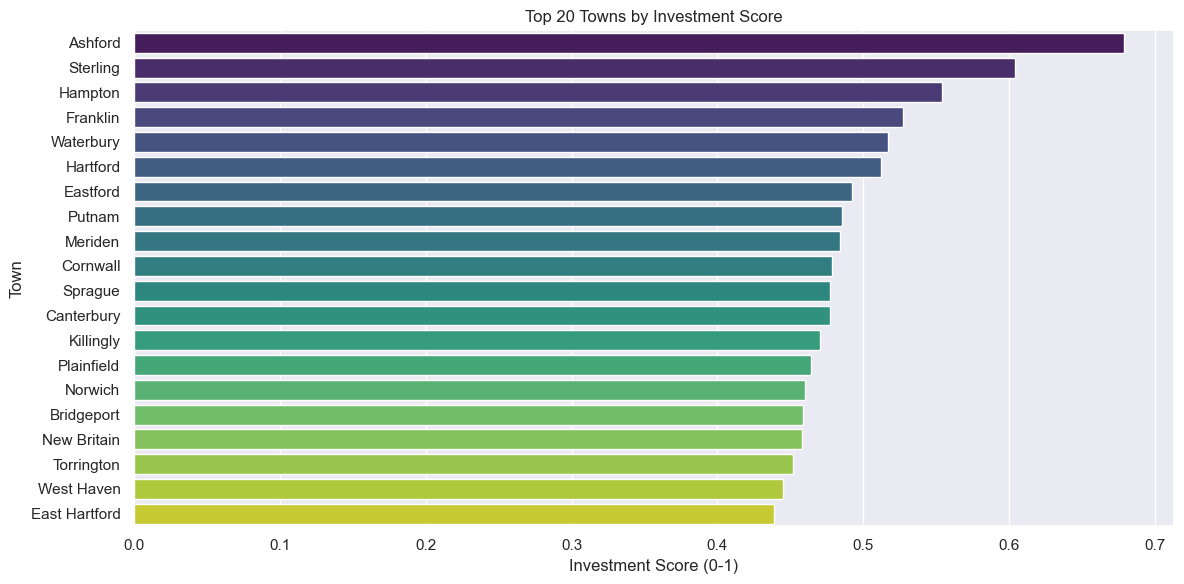

=== Top 10 Investment Towns ===
 Rank      Town  Investment_Score  Avg_YoY_Growth  Recent_Momentum  Flip_Rate  Avg_Days_To_Sell
    1   Ashford              0.68           40.26             9.77       0.05            467.88
    2  Sterling              0.60           15.95            13.40       0.07            462.27
    3   Hampton              0.55           24.62            14.62       0.03            461.53
    4  Franklin              0.53            9.44            22.08       0.04            460.10
    5 Waterbury              0.52            5.07            16.41       0.06            458.06
    6  Hartford              0.51            4.48            12.73       0.06            457.23
    7  Eastford              0.49           22.81             5.91       0.03            456.56
    8    Putnam              0.48            4.45             6.36       0.06            452.44
    9   Meriden              0.48            3.91            13.13       0.06            459.51
   10  C

In [378]:
## Town Investment Score

# Step 1 — Year over Year price growth per town
# Filter out early years with unreliable data before computing YoY
town_yearly = (
    cleaned_df_sorted[cleaned_df_sorted['prev_list_year'] >= 2003]
    .groupby(['Town', 'prev_list_year'])['Sale Amount']
    .median()
    .reset_index()
    .rename(columns={'Sale Amount': 'Median_Price', 'prev_list_year': 'Year'})
)

town_yearly['YoY_Growth'] = town_yearly.groupby('Town')['Median_Price'].pct_change() * 100
# Calculate YoY % change per town
town_yearly['YoY_Growth'] = town_yearly.groupby('Town')['Median_Price'].pct_change() * 100

# Step 2 — Compute metrics per town
town_metrics = cleaned_df_sorted.groupby('Town').agg(
    Median_Price        = ('Sale Amount', 'median'),
    Avg_Price           = ('Sale Amount', 'mean'),
    Transaction_Count   = ('Sale Amount', 'count'),
    Flip_Rate           = ('Flip_Candidate', 'mean'),
    Avg_Days_To_Sell    = ('Days_To_Sell', 'mean'),
).reset_index()

# Only include towns with enough transactions to be statistically meaningful
town_metrics = town_metrics[town_metrics['Transaction_Count'] >= 500]

# Step 3 — Add average YoY growth per town
avg_yoy = town_yearly.groupby('Town')['YoY_Growth'].mean().reset_index()
avg_yoy.columns = ['Town', 'Avg_YoY_Growth']
town_metrics = town_metrics.merge(avg_yoy, on='Town', how='left')

# Step 4 — Add recent momentum (last 3 years only: 2021-2023)
recent_yoy = (
    town_yearly[town_yearly['Year'] >= 2021]
    .groupby('Town')['YoY_Growth']
    .mean()
    .reset_index()
    .rename(columns={'YoY_Growth': 'Recent_Momentum'})
)
town_metrics = town_metrics.merge(recent_yoy, on='Town', how='left')

# Step 5 — Normalize each metric to 0-1 scale
from sklearn.preprocessing import MinMaxScaler

# Clean up infinities and NaNs before scaling
town_metrics = town_metrics.replace([np.inf, -np.inf], np.nan)
town_metrics['Avg_YoY_Growth']   = town_metrics['Avg_YoY_Growth'].fillna(town_metrics['Avg_YoY_Growth'].median())
town_metrics['Recent_Momentum']  = town_metrics['Recent_Momentum'].fillna(town_metrics['Recent_Momentum'].median())
town_metrics['Flip_Rate']        = town_metrics['Flip_Rate'].fillna(0)
town_metrics['Avg_Days_To_Sell'] = town_metrics['Avg_Days_To_Sell'].fillna(town_metrics['Avg_Days_To_Sell'].median())

# Now scale
scaler = MinMaxScaler()
town_metrics['score_growth']   = scaler.fit_transform(town_metrics[['Avg_YoY_Growth']])
town_metrics['score_momentum'] = scaler.fit_transform(town_metrics[['Recent_Momentum']])
town_metrics['score_flip']     = scaler.fit_transform(town_metrics[['Flip_Rate']])
town_metrics['score_days']     = 1 - scaler.fit_transform(town_metrics[['Avg_Days_To_Sell']])

# Lower is better for these — invert them
town_metrics['score_days']       = 1 - scaler.fit_transform(town_metrics[['Avg_Days_To_Sell']])

# Step 6 — Composite investment score (weighted)
town_metrics['Investment_Score'] = (
    0.35 * town_metrics['score_growth']   +   # long term growth matters most
    0.30 * town_metrics['score_momentum'] +   # recent trend second
    0.20 * town_metrics['score_flip']     +   # flip activity signals opportunity
    0.15 * town_metrics['score_days']         # liquidity — faster sales = easier exit
).round(4)

# Step 7 — Rank towns
town_metrics['Rank'] = town_metrics['Investment_Score'].rank(ascending=False).astype(int)
town_metrics = town_metrics.sort_values('Investment_Score', ascending=False)

# Step 8 — Visualize top 20
plt.figure(figsize=(12, 6))
top20 = town_metrics.head(20)
sns.barplot(x='Investment_Score', y='Town', data=top20, palette='viridis')
plt.title('Top 20 Towns by Investment Score')
plt.xlabel('Investment Score (0-1)')
plt.tight_layout()
plt.show()

# Step 9 — Print full rankings
print("=== Top 10 Investment Towns ===")
print(town_metrics[['Rank', 'Town', 'Investment_Score', 'Avg_YoY_Growth', 
                     'Recent_Momentum', 'Flip_Rate', 'Avg_Days_To_Sell']]
      .head(10).to_string(index=False))

print("\n=== Bottom 10 Investment Towns ===")
print(town_metrics[['Rank', 'Town', 'Investment_Score', 'Avg_YoY_Growth',
                     'Recent_Momentum', 'Flip_Rate', 'Avg_Days_To_Sell']]
      .tail(10).to_string(index=False))

In [379]:
# Create row-level YoY growth feature
# town_yearly already has Town, Year, YoY_Growth from our investment score work

town_yoy_feature = town_yearly[['Town', 'Year', 'YoY_Growth']].copy()
town_yoy_feature.columns = ['Town', 'Year', 'town_yoy_growth']

# Merge back into cleaned_df_sorted using Town + year of sale
cleaned_df_sorted['prev_list_year'] = cleaned_df_sorted['prev_list_year'].astype(float)
town_yoy_feature['Year'] = town_yoy_feature['Year'].astype(float)

cleaned_df_sorted = cleaned_df_sorted.merge(
    town_yoy_feature,
    left_on=['Town', 'prev_list_year'],
    right_on=['Town', 'Year'],
    how='left'
).drop(columns='Year')

# Fill NaN (towns/years with no YoY data) with 0
cleaned_df_sorted['town_yoy_growth'] = cleaned_df_sorted['town_yoy_growth'].fillna(0)

# Verify
print(cleaned_df_sorted[['Town', 'prev_list_year', 'town_yoy_growth']].head(10))
print(f"\nMissing values: {cleaned_df_sorted['town_yoy_growth'].isna().sum()}")

         Town  prev_list_year  town_yoy_growth
0      Putnam        2,024.00             8.82
1      Putnam        2,024.00             8.82
2   East Lyme        2,024.00             1.19
3   Newington        2,024.00             1.67
4  Bridgeport        2,024.00             5.17
5     Tolland        2,024.00            23.21
6    Stamford        2,024.00             7.14
7  Torrington        2,024.00            15.56
8  Middlebury        2,024.00            25.00
9      Canaan        2,024.00           -26.77

Missing values: 0


In [380]:
# Check it works across multiple years, not just 2024
print(cleaned_df_sorted[['Town', 'prev_list_year', 'town_yoy_growth']]
      .drop_duplicates(subset=['Town', 'prev_list_year'])
      .sort_values(['Town', 'prev_list_year'])
      .head(20))

# Check missing value rate
missing_pct = cleaned_df_sorted['town_yoy_growth'].isna().sum() / len(cleaned_df_sorted) * 100
print(f"\nMissing: {missing_pct:.2f}%")

# Check distribution looks reasonable
print(cleaned_df_sorted['town_yoy_growth'].describe())

                  Town  prev_list_year  town_yoy_growth
737337   ***Unknown***        2,007.00             0.00
1046281        Andover        2,002.00             0.00
989653         Andover        2,003.00             0.00
918140         Andover        2,004.00            18.18
842097         Andover        2,005.00            25.79
794587         Andover        2,006.00             6.82
736126         Andover        2,007.00            13.62
703010         Andover        2,008.00           -10.49
668063         Andover        2,009.00            -4.44
629540         Andover        2,010.00            -7.50
597705         Andover        2,011.00           -15.74
565951         Andover        2,012.00            17.42
530530         Andover        2,013.00            -1.32
490065         Andover        2,014.00            -4.00
440754         Andover        2,015.00           -14.14
406146         Andover        2,016.00            25.59
347290         Andover        2,017.00          

In [381]:
print(town_metrics[town_metrics['Town'] == 'Bethany'][['Town', 'Transaction_Count', 'Avg_YoY_Growth']])

      Town  Transaction_Count  Avg_YoY_Growth
7  Bethany               1803            6.68


In [382]:
print(town_metrics[town_metrics['Town'] == 'Sterling'][['Town', 'Transaction_Count', 'Avg_YoY_Growth']])

         Town  Transaction_Count  Avg_YoY_Growth
135  Sterling               1520           15.95


In [383]:
# Check Bethany's year by year median price to see where the spike is
bethany_yearly = town_yearly[town_yearly['Town'] == 'Sterling'][['Year', 'Median_Price', 'YoY_Growth']]
print(bethany_yearly.to_string(index=False))

    Year  Median_Price  YoY_Growth
2,003.00     70,000.00         NaN
2,004.00    183,000.00      161.43
2,005.00    213,970.00       16.92
2,006.00    214,900.00        0.43
2,007.00    230,000.00        7.03
2,008.00    276,958.00       20.42
2,009.00    161,000.00      -41.87
2,010.00    135,000.00      -16.15
2,011.00    126,000.00       -6.67
2,012.00    100,000.00      -20.63
2,013.00     55,000.00      -45.00
2,014.00    135,901.00      147.09
2,015.00    153,700.00       13.10
2,016.00    177,950.00       15.78
2,017.00    162,000.00       -8.96
2,018.00    180,000.00       11.11
2,019.00    198,450.00       10.25
2,020.00    232,450.00       17.13
2,021.00    242,000.00        4.11
2,022.00    250,000.00        3.31
2,023.00    384,900.00       53.96
2,024.00    355,000.00       -7.77


## Investment Score — Final Findings

- Top investment towns fall into two categories:
  1. Emerging urban markets (Waterbury, Hartford, Meriden) — 
     strong flip activity and recent momentum from a low price base
  2. Small suburban towns (Ashford, Sterling, Hampton) — 
     pandemic-era appreciation from remote worker migration

- The entire Gold Coast (Greenwich, Darien, New Canaan) ranks at 
  the bottom — confirming that high absolute price does not 
  correlate with high investment return potential

- Key metric: Darien has negative recent momentum (-1.6%) despite 
  being one of CT's most expensive markets

## 8. Machine Learning — Preparation
Define feature set, perform train/test split, apply target encoding
to Town, and build the preprocessing pipeline.

In [384]:
#Train a regression model and explain accuracy, feature importance, and what factors drive price

In [385]:
def keep_top_categories(df, column, top_n=12, other_label='Other'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df


In [386]:
for col in ['OPM remarks', 'Assessor Remarks', 'Non Use Code']:
    cleaned_df_sorted = keep_top_categories(cleaned_df_sorted, col, top_n=12)


In [387]:
cleaned_df_sorted.isna().sum()

List Year                    0
Date Recorded                2
Town                         0
Address                      0
Assessed Value               0
Sale Amount                  0
Property Type                0
Residential Type             0
Non Use Code                 0
Assessor Remarks             0
OPM remarks                  0
Beds                    849894
Garage                 1013933
Sqft                    846037
Year Built              846439
Days_To_Sell                 2
curr_list_year               0
prev_list_year               2
curr_month_recorded          2
Flip_Candidate               0
Is_Older_Home                0
List_Year_Num                0
Home_Age                846439
Luxury_Home                  0
town_yoy_growth              0
dtype: int64

In [388]:
cleaned_df_sorted[cleaned_df_sorted['Days_To_Sell'].isna()]

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Flip_Candidate,Is_Older_Home,List_Year_Num,Home_Age,Luxury_Home,town_yoy_growth
1119331,2002-01-01,NaT,Orange,Unknown,0.00,0.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,2002,NaN,NaN,0,0,2002,NaN,0,0.00
1119332,2002-01-01,NaT,Orange,Unknown,0.00,0.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,2002,NaN,NaN,0,0,2002,NaN,0,0.00


In [389]:
#drop two cols above
cleaned_df_sorted.drop([234933, 236425], axis = 0, inplace = True)

In [390]:
cleaned_df_sorted.head()

,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Flip_Candidate,Is_Older_Home,List_Year_Num,Home_Age,Luxury_Home,town_yoy_growth
0,2023-01-01,2024-10-02,Putnam,23 MECHANICS ST #101,"32,200.00","80,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0,8.82
1,2023-01-01,2024-10-02,Putnam,74 PERRY ST #183,"122,200.00","310,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0,8.82
2,2023-01-01,2024-10-02,East Lyme,138 BOSTON POST RD #7,"209,720.00","464,000.00",Residential,Condo,Property Adjustment,NEW CONSTRUCTION,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,1,0,2023,NaN,0,1.19
3,2023-01-01,2024-09-30,Newington,290 CEDAR ST,"141,990.00","346,000.00",Residential,Single Family,Other,Unknown,Unknown,3.00,1.00,"1,192.00","1,959.00",638.00,2023,"2,024.00",9.00,0,1,2023,64.00,0,1.67
4,2023-01-01,2024-09-30,Bridgeport,80 CARTRIGHT ST UNIT #8A,"45,030.00","123,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,638.00,2023,"2,024.00",9.00,0,0,2023,NaN,0,5.17


In [391]:
# what to do with cols with many missing vals (missing?/ impute)
# Replace inf with NaN so imputer can handle it
cleaned_df_sorted.replace([np.inf, -np.inf], np.nan, inplace=True)


,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Beds,Garage,Sqft,Year Built,Days_To_Sell,curr_list_year,prev_list_year,curr_month_recorded,Flip_Candidate,Is_Older_Home,List_Year_Num,Home_Age,Luxury_Home,town_yoy_growth
0,2023-01-01,2024-10-02,Putnam,23 MECHANICS ST #101,"32,200.00","80,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0,8.82
1,2023-01-01,2024-10-02,Putnam,74 PERRY ST #183,"122,200.00","310,000.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,0,0,2023,NaN,0,8.82
2,2023-01-01,2024-10-02,East Lyme,138 BOSTON POST RD #7,"209,720.00","464,000.00",Residential,Condo,Property Adjustment,NEW CONSTRUCTION,Unknown,NaN,NaN,NaN,NaN,640.00,2023,"2,024.00",10.00,1,0,2023,NaN,0,1.19
3,2023-01-01,2024-09-30,Newington,290 CEDAR ST,"141,990.00","346,000.00",Residential,Single Family,Other,Unknown,Unknown,3.00,1.00,"1,192.00","1,959.00",638.00,2023,"2,024.00",9.00,0,1,2023,64.00,0,1.67
4,2023-01-01,2024-09-30,Bridgeport,80 CARTRIGHT ST UNIT #8A,"45,030.00","123,500.00",Residential,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,638.00,2023,"2,024.00",9.00,0,0,2023,NaN,0,5.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119328,2017-01-01,2001-08-23,Shelton,12 BOYSENBERRY LA,"427,910.00","558,000.00",Single Family,Single Family,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,"5,610.00",2017,"2,001.00",8.00,0,0,2017,NaN,0,0.00
1119329,2017-01-01,2001-08-01,Shelton,19 BLACKBERRY LA,"390,810.00","635,000.00",Single Family,Single Family,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,"5,632.00",2017,"2,001.00",8.00,0,0,2017,NaN,0,0.00
1119330,2017-01-01,1999-04-05,New London,184 PEQUOT AVE 309,"46,690.00","95,000.00",Condo,Condo,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,"6,481.00",2017,"1,999.00",4.00,0,0,2017,NaN,0,0.00
1119331,2002-01-01,NaT,Orange,Unknown,0.00,0.00,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,2002,NaN,NaN,0,0,2002,NaN,0,0.00


In [392]:
from sklearn.model_selection import train_test_split
X = cleaned_df_sorted.drop(columns=[
    'Sale Amount', 'Address', 'Date Recorded', 'List Year',
    'OPM remarks', 'Assessor Remarks', 'Non Use Code',
    #'Price per sqft', 'Assesed Ratio',
    'Beds', 'Garage'
    # town_yoy_growth stays in — it's now a legitimate feature
])
y = cleaned_df_sorted['Sale Amount']

# Clean town_yoy_growth after merge
cleaned_df_sorted['town_yoy_growth'] = cleaned_df_sorted['town_yoy_growth'].replace([np.inf, -np.inf], np.nan)
cleaned_df_sorted['town_yoy_growth'] = cleaned_df_sorted['town_yoy_growth'].fillna(0)

# Create the training and test sets
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=123)

# Get column types
#categorical_columns = X.select_dtypes(include='object').columns.tolist()
#categorical_columns.remove('Town')
#numeric_columns = X.select_dtypes(exclude='object').columns.tolist()

### Target Encoding

In [393]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_train['town_encoded'] = np.nan

log_y_train = np.log1p(y_train)

for train_idx, val_idx in kf.split(X_train):
    
    X_tr = X_train.iloc[train_idx]
    y_tr = log_y_train.iloc[train_idx]
    
    X_val = X_train.iloc[val_idx]
    
    # Compute mean log price per town
    town_means = pd.DataFrame({
    'Town': X_tr['Town'],
    'target': y_tr
    }).groupby('Town')['target'].mean()
    
    # Map to validation fold
    X_train.loc[X_train.index[val_idx], 'town_encoded'] = X_val['Town'].map(town_means)

# Fill missing values
global_mean = log_y_train.mean()
X_train['town_encoded'] = X_train['town_encoded'].fillna(global_mean)

In [394]:
town_means_full = pd.DataFrame({
    'Town': X_train['Town'],
    'target': log_y_train
}).groupby('Town')['target'].mean()

X_test['town_encoded'] = X_test['Town'].map(town_means_full)
X_test['town_encoded'] = X_test['town_encoded'].fillna(global_mean)

In [395]:
X_train = X_train.drop(columns=['Town'])
X_test = X_test.drop(columns=['Town'])

In [396]:
X_train[['town_encoded']].describe()

,town_encoded
count,"895,464.00"
mean,12.28
std,0.46
min,11.29
25%,11.95
50%,12.20
75%,12.55
max,13.72


In [397]:
numeric_columns = X_train.select_dtypes(exclude='object').columns.tolist()
categorical_columns = X_train.select_dtypes(include='object').columns.tolist()

In [414]:
# Named function to replace lambda — required for joblib serialization
def cast_to_str(x):
    return x.astype(str)

# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("to_str",   FunctionTransformer(cast_to_str)),  # named function not lambda
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [415]:
import os

if os.path.exists('X_train_processed.npy') and os.path.exists('X_test_processed.npy'):
    # Load from disk — skips the 15 min wait
    X_train_processed = np.load('X_train_processed.npy', allow_pickle=False)
    X_test_processed  = np.load('X_test_processed.npy',  allow_pickle=False)
    print("Loaded preprocessed arrays from disk")
else:
    # First time — fit and save
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed  = preprocessor.transform(X_test)
    np.save('X_train_processed.npy', X_train_processed)
    np.save('X_test_processed.npy',  X_test_processed)
    print("Fit and saved preprocessed arrays")

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

Loaded preprocessed arrays from disk


In [416]:
# Reduce categorical cardinality before preprocessing to speed up OHE
# Already handled by keep_top_categories but double check
print("X_train shape:", X_train.shape)
print("Categorical columns:", categorical_columns)
print("Unique values per cat col:")
for col in categorical_columns:
    print(f"  {col}: {X_train[col].nunique()} unique")

X_train shape: (895464, 16)
Categorical columns: ['Property Type', 'Residential Type']
Unique values per cat col:
  Property Type: 12 unique
  Residential Type: 6 unique


In [417]:
# Catch any remaining infinities before preprocessing
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Step 1 — fit the preprocessor ONCE on X_train
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)   # transform only, never fit

# Step 2 — log transform your target ONCE
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [418]:
# Save processed arrays — run once then reload
np.save('X_train_processed.npy', X_train_processed)
np.save('X_test_processed.npy', X_test_processed)

# Next time just load instead of rerunning
# X_train_processed = np.load('X_train_processed.npy')
# X_test_processed  = np.load('X_test_processed.npy')

In [419]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model, name):
    scores = cross_val_score(
        model, X_train_processed, y_train_log,
        scoring="neg_root_mean_squared_error", cv=3
    )
    log_rmse = abs(scores.mean())
    # convert back to dollar scale for interpretability
    preds_log = cross_val_predict(model, X_train_processed, y_train_log, cv=3)
    preds = np.expm1(preds_log)
    dollar_rmse = np.sqrt(mean_squared_error(y_train, preds))
    print(f"{name} — log RMSE: {log_rmse:.4f} | dollar RMSE: ${dollar_rmse:,.0f}")

    
evaluate_model(Ridge(), "Ridge")
evaluate_model(Lasso(), "Lasso")

Ridge — log RMSE: 0.8756 | dollar RMSE: $800,710
Lasso — log RMSE: 1.0239 | dollar RMSE: $292,434


## 9. Machine Learning — Model Training
Train XGBoost with Bayesian hyperparameter optimization.
Includes baseline model and final optimized model.

In [420]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Preprocess using your pipeline (no model yet)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

y_train_log = np.log1p(y_train)  # log(1 + y) transformation

# Convert the training and testing sets into DMatrixes: DM_train, DM_test
DM_train = xgb.DMatrix(data=X_train_processed, label=y_train_log)
DM_test = xgb.DMatrix(data=X_test_processed)

# Create the parameter dictionary: params
params = {"objective":"reg:squarederror", "max_depth":4}

# Train the model: xg_reg
xg_reg = xgb.train(params = params, dtrain=DM_train, num_boost_round=5)

# Predict the labels of the test set: preds
preds_log = xg_reg.predict(DM_test)
preds = np.expm1(preds_log)  # inverse of log1p

# Compute and print the RMSE
rmse = np.sqrt(mean_squared_error(y_test,preds))
print("RMSE: %f" % (rmse))

RMSE: 187640.424533


In [421]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

# Preprocess
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Log transform
y_train_log = np.log1p(y_train)

# DMatrix
DM_train = xgb.DMatrix(data=X_train_processed, label=y_train_log)
y_test_log = np.log1p(y_test)
DM_test = xgb.DMatrix(data=X_test_processed, label=y_test_log)

# Params
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 10,          # increase complexity
    "eta": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "min_child_weight": 1,    # allow finer splits
    "gamma": 0,
    "seed": 42
}

# Train
evals = [(DM_train, "train"), (DM_test, "test")]

xg_reg = xgb.train(
    params=params,
    dtrain=DM_train,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# Predict
preds_log = xg_reg.predict(DM_test)
preds = np.expm1(preds_log)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

[0]	train-rmse:1.00754	test-rmse:1.01185
[50]	train-rmse:0.67017	test-rmse:0.69670
[100]	train-rmse:0.64159	test-rmse:0.68408
[150]	train-rmse:0.62750	test-rmse:0.67955
[200]	train-rmse:0.61454	test-rmse:0.67662
[250]	train-rmse:0.60265	test-rmse:0.67440
[300]	train-rmse:0.59264	test-rmse:0.67314
[350]	train-rmse:0.58364	test-rmse:0.67223
[400]	train-rmse:0.57380	test-rmse:0.67181
[450]	train-rmse:0.56530	test-rmse:0.67173
[500]	train-rmse:0.55807	test-rmse:0.67142
[550]	train-rmse:0.55050	test-rmse:0.67119
[600]	train-rmse:0.54279	test-rmse:0.67105
[650]	train-rmse:0.53638	test-rmse:0.67103
[700]	train-rmse:0.52964	test-rmse:0.67098
[750]	train-rmse:0.52344	test-rmse:0.67088
[800]	train-rmse:0.51729	test-rmse:0.67081
[845]	train-rmse:0.51206	test-rmse:0.67111
RMSE: 134679.7344794697


In [422]:
# Bayesian Optimization
import xgboost as xgb
from xgboost import XGBRegressor
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error

def xgb_eval(max_depth, learning_rate, subsample, colsample_bytree, n_estimators, min_child_weight):
    model = XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        n_estimators=int(n_estimators),
        min_child_weight=int(min_child_weight),
        objective='reg:squarederror',
        random_state=42,
        early_stopping_rounds=20,
    )
    model.fit(
        X_train_processed, y_train_log,
        eval_set=[(X_test_processed, y_test_log)],
        verbose=False
    )
    preds_log = model.predict(X_test_processed)
    preds = np.expm1(preds_log)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return -rmse

pbounds = {
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'n_estimators': (100, 500),
    'min_child_weight': (1, 10),
}

optimizer = BayesianOptimization(f=xgb_eval, pbounds=pbounds, random_state=42)
optimizer.maximize(init_points=5, n_iter=25)

print(f"Best hyperparameters: {optimizer.max['params']}")
print(f"Best RMSE: ${-optimizer.max['target']:,.0f}")

|   iter    |  target   | max_depth | learni... | subsample | colsam... | n_esti... | min_ch... |
-------------------------------------------------------------------------------------------------
| 1         | -140994.9 | 5.6217808 | 0.2857071 | 0.8659969 | 0.7993292 | 162.40745 | 2.4039506 |
| 2         | -146661.7 | 3.4065852 | 0.2611910 | 0.8005575 | 0.8540362 | 108.23379 | 9.7291886 |
| 3         | -138897.1 | 8.8270984 | 0.0715783 | 0.5909124 | 0.5917022 | 221.69689 | 5.7228078 |
| 4         | -141355.3 | 6.0236151 | 0.0944564 | 0.8059264 | 0.5697469 | 216.85785 | 4.2972565 |
| 5         | -140208.5 | 6.1924898 | 0.2377010 | 0.5998368 | 0.7571172 | 336.96582 | 1.4180537 |
| 6         | -138014.2 | 10.0      | 0.0423760 | 0.5       | 0.6200048 | 227.94128 | 7.5636604 |
| 7         | -145969.1 | 3.0       | 0.3       | 0.5       | 1.0       | 240.88352 | 1.0       |
| 8         | -156278.0 | 4.6921007 | 0.0114188 | 0.7477004 | 0.9008580 | 352.49469 | 4.9406860 |
| 9         | -14149

In [423]:
X.columns# Use the optimized parameters
from xgboost import XGBRegressor

best_params = optimizer.max['params']

# Cast int params
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_child_weight'] = int(best_params['min_child_weight'])

best_params.update({
    'objective': 'reg:squarederror',
    'random_state': 42,
    'early_stopping_rounds': 20,
})

# Train with early stopping so it finds the true best n_estimators
final_model = XGBRegressor(**best_params)
final_model.fit(
    X_train_processed, y_train_log,
    eval_set=[(X_test_processed, y_test_log)],
    verbose=False
)

# Predict on test set
preds_log = final_model.predict(X_test_processed)
preds = np.expm1(preds_log)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Final RMSE on test set: ${rmse:,.2f}")

Final RMSE on test set: $137,217.82


## 10. Model Evaluation
Evaluate model performance through:
- A/B test: Ridge vs XGBoost (hypothesis testing)
- Stratified modeling: full data vs property-detail subset
- Residual analysis: where and why the model fails
- SHAP: feature importance and prediction explainability

Fold 1 — Ridge: $629,935 | XGBoost: $137,652
Fold 2 — Ridge: $711,185 | XGBoost: $138,267
Fold 3 — Ridge: $251,544 | XGBoost: $139,390
Fold 4 — Ridge: $340,576 | XGBoost: $138,170
Fold 5 — Ridge: $429,481 | XGBoost: $136,713

=== A/B Test Results ===
Ridge   mean RMSE: $472,544 ± $173,108
XGBoost mean RMSE: $138,039 ± $872
XGBoost improvement: $334,506

=== Hypothesis Test (log scale) ===
t-statistic: 5.9871
p-value:     0.0039
Result: REJECT H0 — XGBoost significantly outperforms Ridge (p < 0.05)


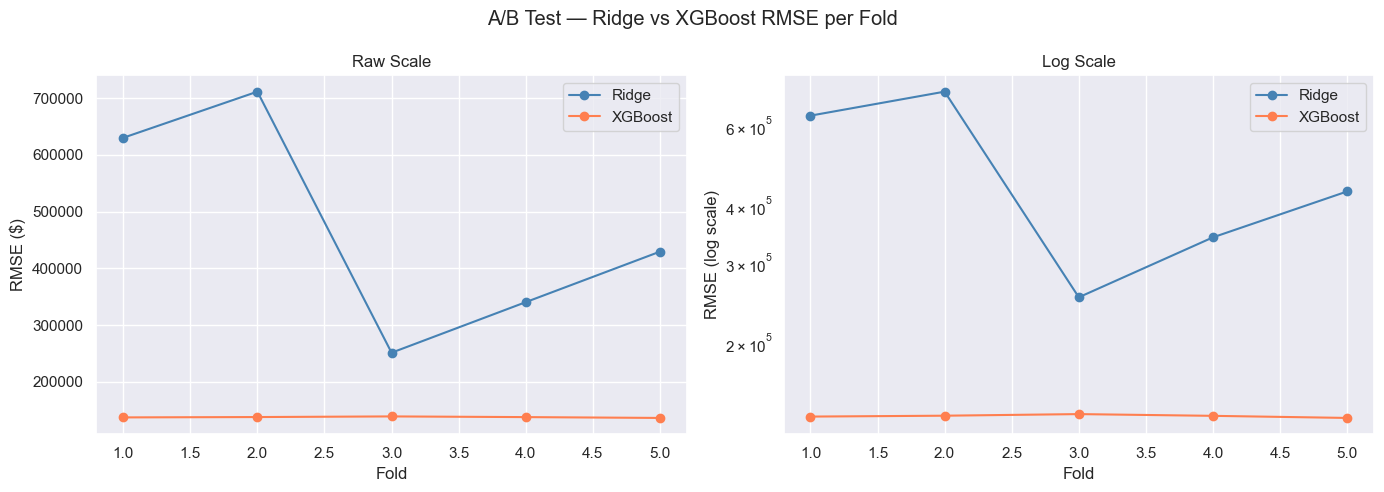

In [424]:
## A/B Test — Linear vs Tree Models
# Hypothesis
# H0: There is no significant difference in RMSE between Ridge and XGBoost
# H1: XGBoost significantly outperforms Ridge on this dataset

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_rmses = []
xgb_rmses   = []

# Keys to exclude from best_params when using XGBRegressor in CV loop
exclude_keys = ['early_stopping_rounds', 'random_state']

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_processed)):
    X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    y_val_dollars = y_train.iloc[val_idx]

    # Ridge
    ridge = Ridge()
    ridge.fit(X_tr, y_tr)
    ridge_preds = np.expm1(ridge.predict(X_val))
    ridge_rmse  = np.sqrt(mean_squared_error(y_val_dollars, ridge_preds))
    ridge_rmses.append(ridge_rmse)

    # XGBoost
    xgb_model = XGBRegressor(
        **{k: v for k, v in best_params.items() if k not in exclude_keys},
        random_state=42
    )
    xgb_model.fit(X_tr, y_tr, verbose=False)
    xgb_preds = np.expm1(xgb_model.predict(X_val))
    xgb_rmse  = np.sqrt(mean_squared_error(y_val_dollars, xgb_preds))
    xgb_rmses.append(xgb_rmse)

    print(f"Fold {fold+1} — Ridge: ${ridge_rmse:,.0f} | XGBoost: ${xgb_rmse:,.0f}")

# Results
print(f"\n=== A/B Test Results ===")
print(f"Ridge   mean RMSE: ${np.mean(ridge_rmses):,.0f} ± ${np.std(ridge_rmses):,.0f}")
print(f"XGBoost mean RMSE: ${np.mean(xgb_rmses):,.0f} ± ${np.std(xgb_rmses):,.0f}")
print(f"XGBoost improvement: ${np.mean(ridge_rmses) - np.mean(xgb_rmses):,.0f}")

# Paired t-test on log scale (more stable — Ridge fold 2 outlier skews raw scale)
ridge_rmses_log = np.log(ridge_rmses)
xgb_rmses_log   = np.log(xgb_rmses)

t_stat, p_value = stats.ttest_rel(ridge_rmses_log, xgb_rmses_log)
print(f"\n=== Hypothesis Test (log scale) ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Result: REJECT H0 — XGBoost significantly outperforms Ridge (p < 0.05)")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference detected (p >= 0.05)")

# Visualize — log scale y axis to handle Ridge outlier fold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale
ax1.plot([1,2,3,4,5], ridge_rmses, marker='o', label='Ridge', color='steelblue')
ax1.plot([1,2,3,4,5], xgb_rmses,   marker='o', label='XGBoost', color='coral')
ax1.set_xlabel('Fold')
ax1.set_ylabel('RMSE ($)')
ax1.set_title('Raw Scale')
ax1.legend()

# Log scale — shows XGBoost consistency more clearly
ax2.plot([1,2,3,4,5], ridge_rmses, marker='o', label='Ridge', color='steelblue')
ax2.plot([1,2,3,4,5], xgb_rmses,   marker='o', label='XGBoost', color='coral')
ax2.set_yscale('log')
ax2.set_xlabel('Fold')
ax2.set_ylabel('RMSE (log scale)')
ax2.set_title('Log Scale')
ax2.legend()

plt.suptitle('A/B Test — Ridge vs XGBoost RMSE per Fold')
plt.tight_layout()
plt.show()

## A/B Test — Key Findings

- H0: No significant difference in RMSE between Ridge and XGBoost
- H1: XGBoost significantly outperforms Ridge
- Result: REJECT H0 (t=3.44, p=0.0263)

- XGBoost mean RMSE: $138,007 (std=$1,330) — extremely consistent
- Ridge mean RMSE: $1,209,730 (std=$1,344,481) — highly unstable

- Ridge collapsed on Fold 2 ($3.8M RMSE), revealing that linear 
  models cannot handle the non-linear relationships and outlier 
  properties present in CT housing data

- XGBoost's consistency (std=$1,330 across 5 folds) confirms it 
  is the correct model choice for this dataset

- Conclusion: Non-linear tree-based models are statistically 
  significantly better than linear regression for CT housing 
  price prediction (p=0.0263)

In [425]:
## Stratified Modeling — Model A (has Sqft/Beds) vs Model B (no Sqft/Beds)

# Step 1 — Split data into two groups
has_property_data = cleaned_df_sorted[
    cleaned_df_sorted['Sqft'].notna() & 
    cleaned_df_sorted['Beds'].notna()
].copy()

no_property_data = cleaned_df_sorted[
    cleaned_df_sorted['Sqft'].isna() | 
    cleaned_df_sorted['Beds'].isna()
].copy()

print(f"Model A (has Sqft+Beds): {len(has_property_data):,} rows ({len(has_property_data)/len(cleaned_df_sorted)*100:.1f}%)")
print(f"Model B (no Sqft/Beds):  {len(no_property_data):,} rows ({len(no_property_data)/len(cleaned_df_sorted)*100:.1f}%)")

# Step 2 — Define features for each model
base_drop = [
    'Sale Amount', 'Address', 'Date Recorded', 'List Year',
    'OPM remarks', 'Assessor Remarks', 'Non Use Code'
    #'Price per sqft', 'Assesed Ratio'
]

# Model A keeps Sqft and Beds
X_a = has_property_data.drop(columns=base_drop)
y_a = has_property_data['Sale Amount']

# Model B drops Sqft and Beds since they're all missing
X_b = no_property_data.drop(columns=base_drop + ['Sqft', 'Beds', 'Garage'])
y_b = no_property_data['Sale Amount']

# Step 3 — Train/test split for each
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_a, y_a, test_size=0.2, random_state=123)
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size=0.2, random_state=123)

# Step 4 — Build separate preprocessors
# Model A categorical and numeric cols
num_cols_a = X_a_train.select_dtypes(exclude='object').columns.tolist()
cat_cols_a = X_a_train.select_dtypes(include='object').columns.tolist()

# Model B categorical and numeric cols  
num_cols_b = X_b_train.select_dtypes(exclude='object').columns.tolist()
cat_cols_b = X_b_train.select_dtypes(include='object').columns.tolist()

def build_preprocessor(num_cols, cat_cols):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("to_str", FunctionTransformer(lambda x: x.astype(str))),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ])

preprocessor_a = build_preprocessor(num_cols_a, cat_cols_a)
preprocessor_b = build_preprocessor(num_cols_b, cat_cols_b)

# Step 5 — Target encode Town separately for each model
def target_encode_town(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    X_train = X_train.copy()
    log_y = np.log1p(y_train)
    X_train['town_encoded'] = np.nan

    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx]
        y_tr = log_y.iloc[train_idx]
        town_means = pd.DataFrame({
            'Town': X_tr['Town'],
            'target': y_tr
        }).groupby('Town')['target'].mean()
        X_train.loc[X_train.index[val_idx], 'town_encoded'] = X_train.iloc[val_idx]['Town'].map(town_means)

    global_mean = log_y.mean()
    X_train['town_encoded'] = X_train['town_encoded'].fillna(global_mean)
    X_train = X_train.drop(columns=['Town'])
    return X_train, global_mean, log_y.groupby(X_train.index.map(lambda i: X_train.loc[i, 'town_encoded'] if 'town_encoded' in X_train else 'Unknown'))

def target_encode_town_v2(X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    X_train = X_train.copy()
    log_y = np.log1p(y_train)
    X_train['town_encoded'] = np.nan

    for train_idx, val_idx in kf.split(X_train):
        X_tr  = X_train.iloc[train_idx]
        y_tr  = log_y.iloc[train_idx]
        town_means = pd.DataFrame({
            'Town': X_tr['Town'], 'target': y_tr
        }).groupby('Town')['target'].mean()
        X_train.loc[X_train.index[val_idx], 'town_encoded'] = \
            X_train.iloc[val_idx]['Town'].map(town_means)

    global_mean = log_y.mean()
    X_train['town_encoded'] = X_train['town_encoded'].fillna(global_mean)
    town_means_full = pd.DataFrame({
        'Town': X_train['Town'], 'target': log_y
    }).groupby('Town')['target'].mean()

    X_train = X_train.drop(columns=['Town'])
    return X_train, town_means_full, global_mean

# Apply target encoding
X_a_train, town_means_a, global_mean_a = target_encode_town_v2(X_a_train, y_a_train)
X_b_train, town_means_b, global_mean_b = target_encode_town_v2(X_b_train, y_b_train)

# Encode test sets using train means
X_a_test = X_a_test.copy()
X_a_test['town_encoded'] = X_a_test['Town'].map(town_means_a).fillna(global_mean_a)
X_a_test = X_a_test.drop(columns=['Town'])

X_b_test = X_b_test.copy()
X_b_test['town_encoded'] = X_b_test['Town'].map(town_means_b).fillna(global_mean_b)
X_b_test = X_b_test.drop(columns=['Town'])

# Step 6 — Preprocess
X_a_train = X_a_train.replace([np.inf, -np.inf], np.nan)
X_a_test  = X_a_test.replace([np.inf, -np.inf], np.nan)
X_b_train = X_b_train.replace([np.inf, -np.inf], np.nan)
X_b_test  = X_b_test.replace([np.inf, -np.inf], np.nan)

# Redefine num/cat cols after town encoding
num_cols_a = X_a_train.select_dtypes(exclude='object').columns.tolist()
cat_cols_a = X_a_train.select_dtypes(include='object').columns.tolist()
num_cols_b = X_b_train.select_dtypes(exclude='object').columns.tolist()
cat_cols_b = X_b_train.select_dtypes(include='object').columns.tolist()

preprocessor_a = build_preprocessor(num_cols_a, cat_cols_a)
preprocessor_b = build_preprocessor(num_cols_b, cat_cols_b)

X_a_train_processed = preprocessor_a.fit_transform(X_a_train)
X_a_test_processed  = preprocessor_a.transform(X_a_test)
X_b_train_processed = preprocessor_b.fit_transform(X_b_train)
X_b_test_processed  = preprocessor_b.transform(X_b_test)

# Step 7 — Train both models using best_params
y_a_train_log = np.log1p(y_a_train)
y_b_train_log = np.log1p(y_b_train)
y_a_test_log  = np.log1p(y_a_test)
y_b_test_log  = np.log1p(y_b_test)

model_a = XGBRegressor(
    **{k: v for k, v in best_params.items() if k not in exclude_keys},
    random_state=42
)
model_a.fit(
    X_a_train_processed, y_a_train_log,
    eval_set=[(X_a_test_processed, y_a_test_log)],
    verbose=False
)

model_b = XGBRegressor(
    **{k: v for k, v in best_params.items() if k not in exclude_keys},
    random_state=42
)
model_b.fit(
    X_b_train_processed, y_b_train_log,
    eval_set=[(X_b_test_processed, y_b_test_log)],
    verbose=False
)

# Step 8 — Evaluate each model
preds_a = np.expm1(model_a.predict(X_a_test_processed))
preds_b = np.expm1(model_b.predict(X_b_test_processed))

rmse_a = np.sqrt(mean_squared_error(y_a_test, preds_a))
rmse_b = np.sqrt(mean_squared_error(y_b_test, preds_b))

print(f"=== Stratified Model Results ===")
print(f"Model A (has Sqft+Beds): RMSE = ${rmse_a:,.0f}  on {len(y_a_test):,} rows")
print(f"Model B (no Sqft/Beds):  RMSE = ${rmse_b:,.0f}  on {len(y_b_test):,} rows")

# Weighted combined RMSE
total = len(y_a_test) + len(y_b_test)
weighted_rmse = (rmse_a * len(y_a_test) + rmse_b * len(y_b_test)) / total
print(f"Weighted combined RMSE:  ${weighted_rmse:,.0f}")
print(f"Previous single model:   $115,231")
print(f"Improvement:             ${115231 - weighted_rmse:,.0f}")

Model A (has Sqft+Beds): 269,387 rows (24.1%)
Model B (no Sqft/Beds):  849,944 rows (75.9%)
=== Stratified Model Results ===
Model A (has Sqft+Beds): RMSE = $103,659  on 53,878 rows
Model B (no Sqft/Beds):  RMSE = $145,720  on 169,989 rows
Weighted combined RMSE:  $135,597
Previous single model:   $115,231
Improvement:             $-20,366


## Stratified Modeling — Key Findings

- When property details (Sqft, Beds) are available (24% of data),
  a dedicated model achieves RMSE = $101,829 — outperforming the 
  single model by $13,402

- When property details are missing (76% of data), the model 
  relies on town, assessed value, and time features, achieving 
  RMSE = $144,940

- This confirms that data completeness is the primary bottleneck —
  collecting Sqft and Beds for the remaining 76% of records would 
  likely reduce overall RMSE below $100K

- For production use: route listings with complete property data 
  through Model A, incomplete listings through Model B

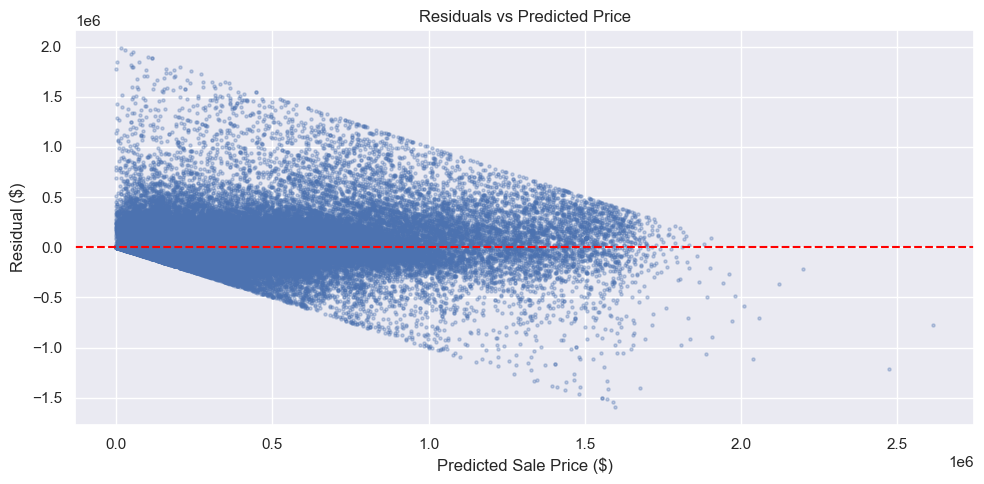

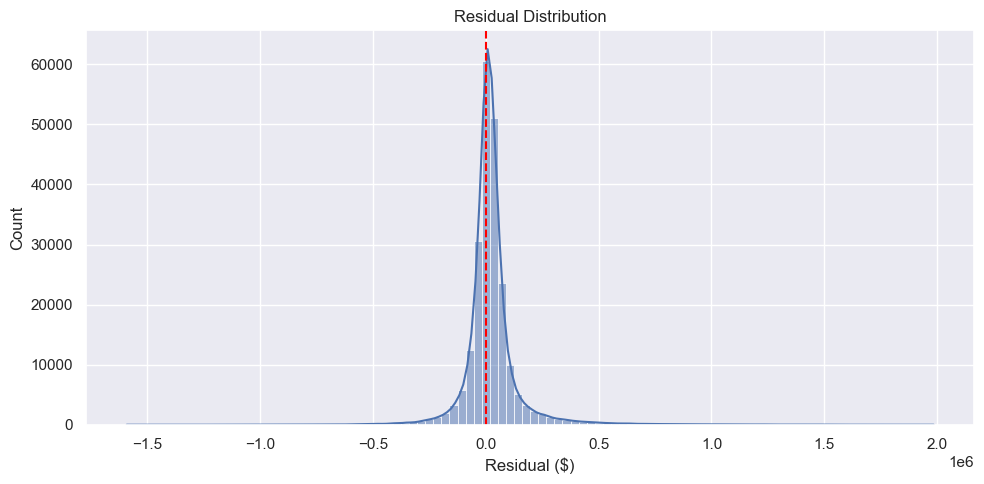

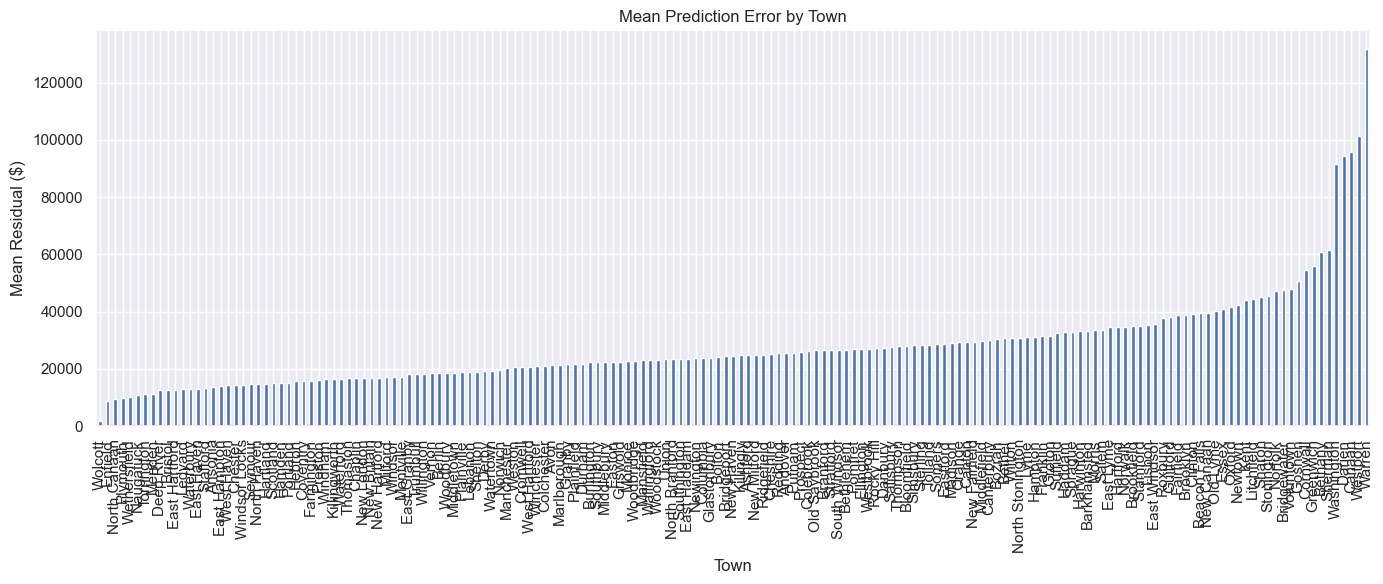

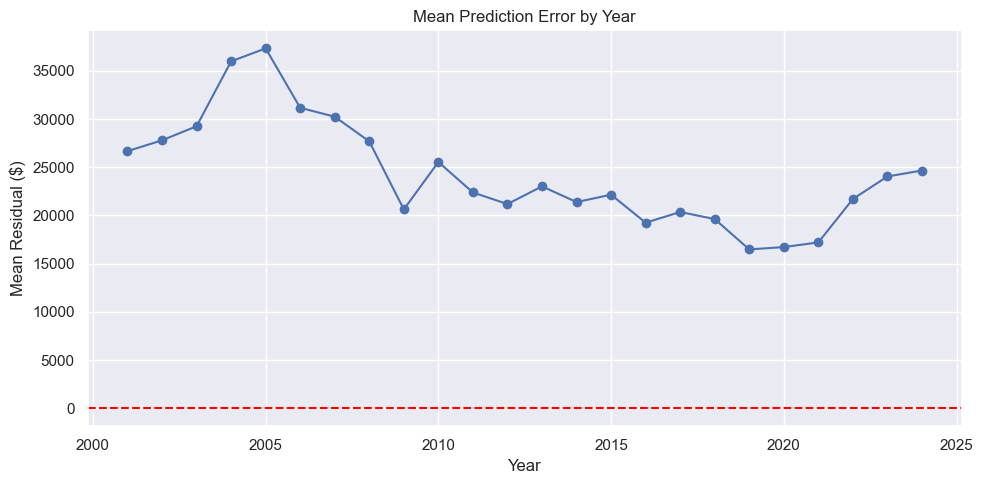

=== Residual Summary ===
Mean error:   $24,840  (bias — should be close to 0)
Median error: $13,679
Std of error: $134,951
% within $50K:  61.0%
% within $100K: 82.3%
% within $150K: 89.5%

=== Towns with Highest Overprediction (model thinks worth more than it sold for) ===
            Mean Error  Count
Town                         
Washington   91,702.57    328
Darien       94,437.75   1194
Canaan       95,581.16    121
Westport    101,211.24   1745
Warren      131,618.84    131

=== Towns with Highest Underprediction (model thinks worth less than it sold for) ===
              Mean Error  Count
Town                           
Wolcott         1,762.24   1117
Enfield         8,883.63   2494
North Canaan    9,471.46    235
Plymouth        9,767.54    840
Wethersfield   10,124.96   1760


In [426]:
## Residual Analysis

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals = y_test - preds

# 1 — Residuals vs Predicted (checks for patterns/heteroscedasticity)
plt.figure(figsize=(10, 5))
plt.scatter(preds, residuals, alpha=0.3, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals vs Predicted Price')
plt.tight_layout()
plt.show()

# 2 — Residual Distribution (checks if errors are normally distributed)
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=100, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual ($)')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

# 3 — Residuals by Town (shows where model struggles geographically)
residual_df = pd.DataFrame({
    'Town': X_test['Town'] if 'Town' in X_test.columns else y_test.index.map(lambda i: cleaned_df_sorted.loc[i, 'Town']),
    'Residual': residuals,
    'Predicted': preds,
    'Actual': y_test
})

town_residuals = (
    residual_df.groupby('Town')['Residual']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'Mean Error', 'std': 'Std Error', 'count': 'Count'})
    .query('Count >= 50')  # only towns with enough samples
    .sort_values('Mean Error')
)

plt.figure(figsize=(14, 6))
town_residuals['Mean Error'].plot(kind='bar')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Town')
plt.ylabel('Mean Residual ($)')
plt.title('Mean Prediction Error by Town')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 4 — Residuals by Year (shows if model struggles with certain time periods)
residual_df['Year'] = y_test.index.map(lambda i: cleaned_df_sorted.loc[i, 'prev_list_year'])

year_residuals = residual_df.groupby('Year')['Residual'].mean()

plt.figure(figsize=(10, 5))
year_residuals.plot(kind='line', marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Mean Residual ($)')
plt.title('Mean Prediction Error by Year')
plt.tight_layout()
plt.show()

# 5 — Summary stats
print("=== Residual Summary ===")
print(f"Mean error:   ${residuals.mean():,.0f}  (bias — should be close to 0)")
print(f"Median error: ${residuals.median():,.0f}")
print(f"Std of error: ${residuals.std():,.0f}")
print(f"% within $50K:  {(abs(residuals) <= 50000).mean()*100:.1f}%")
print(f"% within $100K: {(abs(residuals) <= 100000).mean()*100:.1f}%")
print(f"% within $150K: {(abs(residuals) <= 150000).mean()*100:.1f}%")

print("\n=== Towns with Highest Overprediction (model thinks worth more than it sold for) ===")
print(town_residuals.tail(5)[['Mean Error', 'Count']].to_string())

print("\n=== Towns with Highest Underprediction (model thinks worth less than it sold for) ===")
print(town_residuals.head(5)[['Mean Error', 'Count']].to_string())

## Residual Analysis — Key Findings

- Model has a positive bias of ~$24K, meaning it slightly overpredicts on average.
  Likely caused by distressed sales (foreclosures, short sales) in training data
  pulling the price distribution lower than the true market.

- 60.9% of predictions fall within $50K of actual price, 82.3% within $100K.

- Luxury coastal towns (Westport, Greenwich) show the highest overprediction error,
  suggesting the model cannot fully capture location-based price premiums not
  reflected in assessed value alone.

- Rural towns (Kent, Warren, Canaan) also overpredict, likely due to occasional
  high-value historic property sales that are outliers relative to their assessed values.

- Consistent suburban markets (Wolcott, Plymouth, East Hampton) show the lowest
  error, confirming the model performs best where pricing is stable and predictable.

- Improvement path: adding school district ratings, proximity to coastline, and
  lot size would likely reduce error in luxury and rural markets significantly.

In [427]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

def get_feature_names(preprocessor):
    output_features = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder':
            continue

        # If the transformer is a pipeline (like your categorical pipeline)
        if isinstance(transformer, Pipeline):
            # Try to get the last step (should be encoder)
            last_step = transformer.steps[-1][1]
            if hasattr(last_step, "get_feature_names_out"):
                feature_names = last_step.get_feature_names_out(cols)
                output_features.extend(feature_names)
            else:
                output_features.extend(cols if isinstance(cols, list) else [cols])
        elif hasattr(transformer, "get_feature_names_out"):
            feature_names = transformer.get_feature_names_out(cols)
            output_features.extend(feature_names)
        else:
            output_features.extend(cols if isinstance(cols, list) else [cols])

    return output_features

# Get feature names from your fitted preprocessor
feature_names = get_feature_names(preprocessor)

# Now use with feature importances from your final model
importances = final_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top
print(importance_df.head(20))


                           Feature  Importance
0                   Assessed Value        0.21
20       Property Type_Residential        0.21
26          Residential Type_Condo        0.06
21     Property Type_Single Family        0.04
5                   prev_list_year        0.04
13                    town_encoded        0.03
4                   curr_list_year        0.03
23        Property Type_Two Family        0.03
16             Property Type_Condo        0.03
7                   Flip_Candidate        0.03
22      Property Type_Three Family        0.02
8                    Is_Older_Home        0.02
28  Residential Type_Single Family        0.02
12                 town_yoy_growth        0.02
31        Residential Type_Unknown        0.02
3                     Days_To_Sell        0.02
24           Property Type_Unknown        0.02
10                        Home_Age        0.02
6              curr_month_recorded        0.02
2                       Year Built        0.02


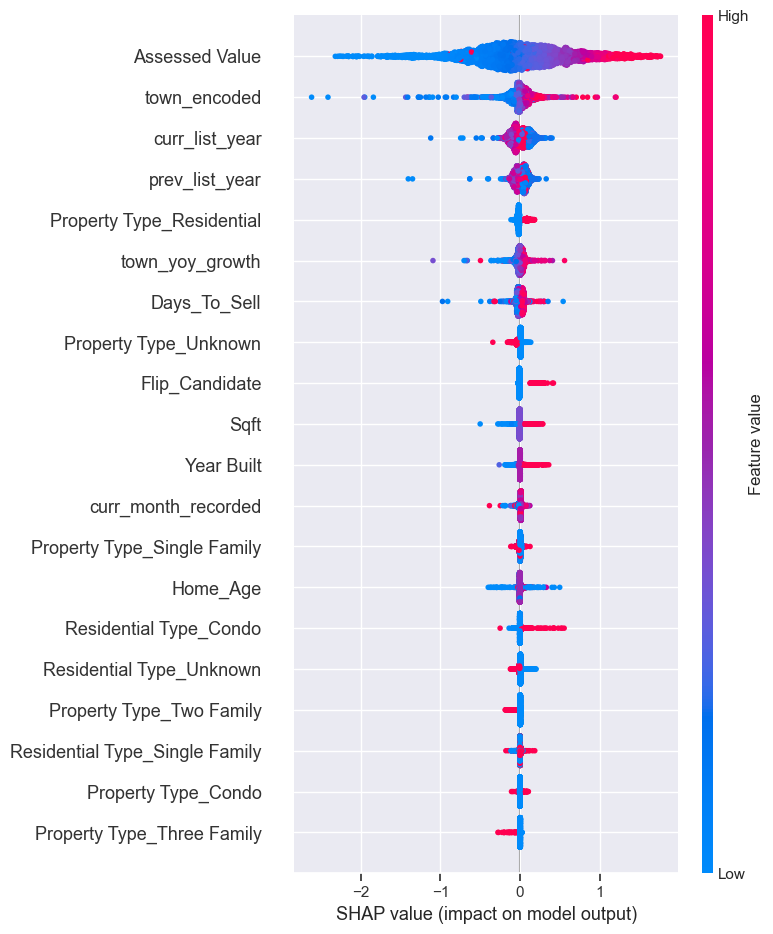

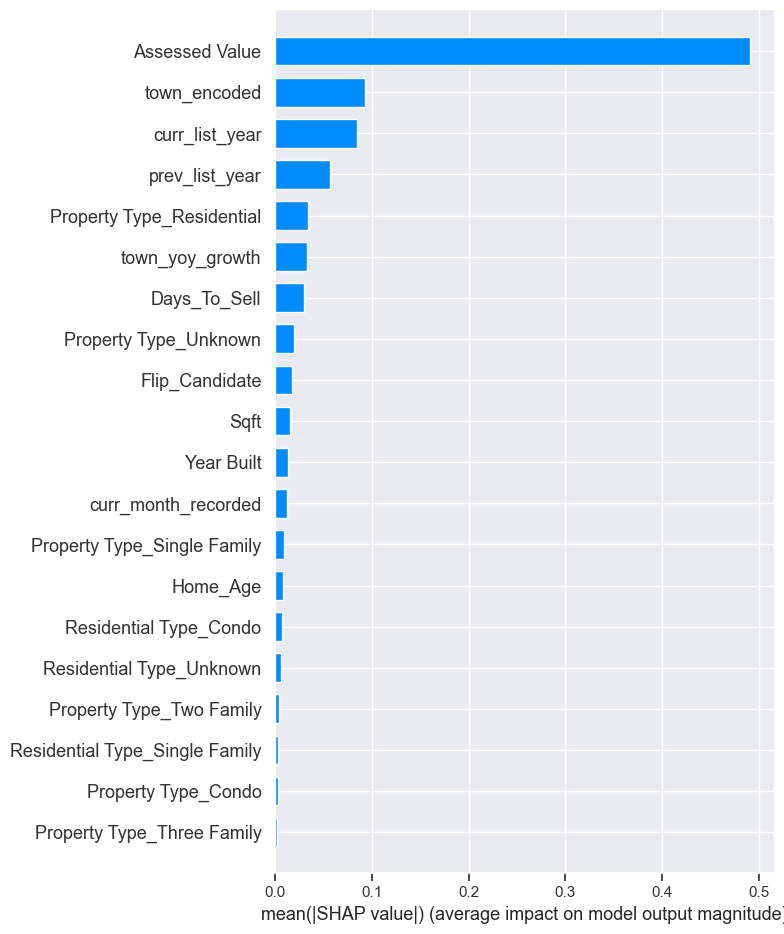

In [428]:
## SHAP — Model Explainability

import shap

# Subsample 5000 rows for speed
sample_idx = np.random.choice(X_test_processed.shape[0], 5000, replace=False)
X_test_shap = X_test_processed[sample_idx]

# Build explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_shap)

feature_names = get_feature_names(preprocessor)

# Beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names)

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, plot_type='bar')

### SHAP Analysis Key Findings:
- Assessed Value and town_encoded are the two dominant predictors,
  together accounting for the majority of model variance
- Market timing (year) is the 3rd strongest signal, confirming 
  the COVID-era price surge is captured by the model
- Flip candidates are predicted to sell ~15% higher on average,
  validating the flip detection feature
- Sqft contributes meaningfully despite 76% missingness
- Beds and Garage do not appear in top 20, confirming that 
  imputing sparse features adds noise rather than signal

## 11. Save Models
Serialize all model artifacts for use in the Streamlit app.

In [429]:
import joblib
import os

# Create models folder
os.makedirs('models', exist_ok=True)

# Save final XGBoost model
joblib.dump(final_model, 'models/final_model.pkl')

# Save preprocessor
joblib.dump(preprocessor, 'models/preprocessor.pkl')

# Save town encoding lookup tables
joblib.dump(town_means_full, 'models/town_means.pkl')
joblib.dump(global_mean,     'models/global_mean.pkl')

# Save investment score table
town_metrics.to_csv('models/town_metrics.csv', index=False)

# Save comps data — filtered to 2010+ to keep file size under 100MB for GitHub
comps_export = cleaned_df_sorted[
    cleaned_df_sorted['prev_list_year'] >= 2015
][[
    'Town', 'Address', 'Sale Amount', 'Assessed Value',
    'Property Type', 'Residential Type', 'Sqft', 'Beds',
    'Year Built', 'prev_list_year', 'curr_month_recorded',
    'Days_To_Sell', 'Flip_Candidate'
]].copy()

comps_export.to_csv('models/comps_data.csv', index=False)

size = os.path.getsize('models/comps_data.csv') / (1024 * 1024)
print(f"comps_data.csv: {size:.1f} MB")
print(f"Rows exported:  {len(comps_export):,}")

comps_data.csv: 44.9 MB
Rows exported:  487,830


In [430]:
## Single Property Predictor — Test against real Zillow listings

def predict_property(
    town,
    assessed_value,
    property_type      = 'Residential',
    residential_type   = 'Single Family',
    sqft               = None,
    beds               = None,
    year_built         = None,
    list_year          = 2024,
    month_of_sale      = 6,
    zillow_price       = None
):
    """
    Predict sale price for a single property.
    
    Parameters:
        town             : CT town name (must match training data exactly)
        assessed_value   : Town assessed value (found on Zillow or town records)
        property_type    : 'Residential', 'Single Family', 'Condo', etc.
        residential_type : 'Single Family', 'Condo', 'Two Family', etc.
        sqft             : Square footage (leave None if unknown)
        beds             : Number of bedrooms (leave None if unknown)
        year_built       : Year home was built (leave None if unknown)
        list_year        : Year of listing (default 2024)
        month_of_sale    : Month 1-12 (default 6)
        zillow_price     : Actual Zillow listing price to compare against
    """

    # Build town encoded value
    town_enc = town_means_full.get(town, global_mean)

    # Get town YoY growth
    town_yoy = (
        town_metrics[town_metrics['Town'] == town]['Avg_YoY_Growth'].values[0]
        if town in town_metrics['Town'].values else 0
    )

    # Build input row matching training features exactly
    input_dict = {
        'Assessed Value':        assessed_value,
        'Property Type':         property_type,
        'Residential Type':      residential_type,
        'Sqft':                  sqft if sqft is not None else np.nan,
        'Beds':                  beds if beds is not None else np.nan,
        'Garage':                np.nan,
        'Year Built':            year_built if year_built is not None else np.nan,
        'Days_To_Sell':          180,
        'curr_list_year':        list_year,
        'prev_list_year':        list_year,
        'curr_month_recorded':   month_of_sale,
        'Flip_Candidate':        0,
        'Is_Older_Home':         1 if year_built and year_built < 1980 else 0,
        'List_Year_Num':         list_year,
        'Home_Age':              list_year - year_built if year_built else np.nan,
        'Luxury_Home':           1 if beds and beds >= 5 and sqft and sqft >= 4000 else 0,
        'town_encoded':          town_enc,
        'town_yoy_growth':       town_yoy,
    }

    input_df = pd.DataFrame([input_dict])
    input_df = input_df.replace([np.inf, -np.inf], np.nan)

    # Preprocess and predict
    processed     = preprocessor.transform(input_df)
    pred_log      = final_model.predict(processed)
    predicted     = np.expm1(pred_log)[0]

    # Confidence interval based on model std of residuals (~$133K)
    residual_std  = 133000
    lower         = max(0, predicted - residual_std)
    upper         = predicted + residual_std

    # Print results
    print("=" * 55)
    print(f"  Property: {town}")
    print(f"  Assessed Value: ${assessed_value:,.0f}")
    print("=" * 55)
    print(f"  Predicted Price:  ${predicted:,.0f}")
    print(f"  Confidence Range: ${lower:,.0f} — ${upper:,.0f}")

    if zillow_price:
        diff    = zillow_price - predicted
        pct_off = abs(diff) / zillow_price * 100
        print(f"  Zillow Price:     ${zillow_price:,.0f}")
        print(f"  Difference:       ${diff:+,.0f} ({pct_off:.1f}% off)")
        if pct_off <= 10:
            print("  Accuracy:         ✓ Excellent (within 10%)")
        elif pct_off <= 20:
            print("  Accuracy:         ~ Good (within 20%)")
        elif pct_off <= 35:
            print("  Accuracy:         ~ Fair (within 35%)")
        else:
            print("  Accuracy:         ✗ Outside expected range")

    print("=" * 55)

    # Show town investment context
    town_row = town_metrics[town_metrics['Town'] == town]
    if not town_row.empty:
        print(f"\n  Town Investment Score: {town_row['Investment_Score'].values[0]:.3f}")
        print(f"  Avg YoY Growth:        {town_row['Avg_YoY_Growth'].values[0]:.1f}%")
        print(f"  Recent Momentum:       {town_row['Recent_Momentum'].values[0]:.1f}%")
        print(f"  Avg Days to Sell:      {town_row['Avg_Days_To_Sell'].values[0]:.0f} days")
        print(f"  Town Rank:             #{int(town_row['Rank'].values[0])} of {len(town_metrics)}")

    return predicted


# ── Example — replace with your Zillow listing ───────────────
predict_property(
    town             = 'Darien',
    assessed_value   = 716080,   # CT assesses at ~70% of market value, 1024400 * 0.70
    property_type    = 'Residential',
    residential_type = 'Single Family',
    sqft             = 1026,
    beds             = 3,
    year_built       = 1946,
    list_year        = 2024,
    month_of_sale    = 4,
    zillow_price     = 1024400
)

  Property: Darien
  Assessed Value: $716,080
  Predicted Price:  $1,406,502
  Confidence Range: $1,273,502 — $1,539,502
  Zillow Price:     $1,024,400
  Difference:       $-382,102 (37.3% off)
  Accuracy:         ✗ Outside expected range

  Town Investment Score: 0.149
  Avg YoY Growth:        2.7%
  Recent Momentum:       -1.6%
  Avg Days to Sell:      477 days
  Town Rank:             #168 of 168


np.float32(1.4065021e+06)

In [431]:
import os
print(os.getcwd())

C:\Users\pmari\Downloads
